# Summarize the Results

In [1]:
import os
import re
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import pandas as pandas
import matplotlib.pyplot as plt

from typing import Union

/home/stud/kgutjahr/miniconda3/envs/stil/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_PATH = "/data/local/kgutjahr/results/test/runs/eval/ADNI"

In [3]:
BASE_DVM_PATH = "/data/local/kgutjahr/results/test/runs/eval/DVM"

In [4]:
MET_DICT = {"multimodal.test.classifier.entropy": r"$f_{m}$ Entropy",
            "image.test.classifier.entropy": r"$f_{i}$ Entropy",
            "tabular.test.classifier.entropy": r"$f_{t}$ Entropy",
            "test.acc": "Accuracy (Test)",
            "test.balanced_acc": "Balanced Accuracy (Test)",
            "test.expert_no0.entropy": r"$f_{0}$ Entropy",
            "test.expert_no1.entropy": r"$f_{1}$ Entropy",
            "test.expert_no2.entropy": r"$f_{2}$ Entropy",
            "val.balanced_acc": "Balanced Accuracy (Validation)",
            "eval.val.acc": "Accuracy (Validation)",
            "MoE.test.weight0": r"Gate weight for $f_{m}$",
            "MoE.test.weight1": r"Gate weight for $f_{i}$",
            "MoE.test.weight2": r"Gate weight for $f_{t}$",
            "MoE.test.x_ai.class_prob_0": r"Ratio of $\mathit{z}_{s}^{i}$ being sent to $f_{1}$",
            "MoE.test.x_ai.class_prob_1": r"Ratio of $\mathit{z}_{s}^{i}$ being sent to $f_{2}$",
            "MoE.test.x_ai.class_prob_2": r"Ratio of $\mathit{z}_{s}^{i}$ being sent to $f_{3}$",
            "MoE.test.x_si_enhance.class_prob_0": r"Ratio of $\hat{\mathit{z}}_{i}^{t}$ being sent to $f_{1}$",
            "MoE.test.x_si_enhance.class_prob_1": r"Ratio of $\hat{\mathit{z}}_{i}^{t}$ being sent to $f_{2}$",
            "MoE.test.x_si_enhance.class_prob_2": r"Ratio of $\hat{\mathit{z}}_{i}^{t}$ being sent to $f_{3}$",
            "MoE.test.x_c.class_prob_0": r"Ratio of $\hat{\mathit{z}}_{t}$ being sent to $f_{1}$",
            "MoE.test.x_c.class_prob_1": r"Ratio of $\hat{\mathit{z}}_{t}$ being sent to $f_{2}$",
            "MoE.test.x_c.class_prob_2": r"Ratio of $\hat{\mathit{z}}_{t}$ being sent to $f_{3}$",
            "MoE.test.x_st_enhance.class_prob_0": r"Ratio of $\hat{\mathit{z}}_{c}^{t}$ being sent to $f_{1}$",
            "MoE.test.x_st_enhance.class_prob_1": r"Ratio of $\hat{\mathit{z}}_{c}^{t}$ being sent to $f_{2}$",
            "MoE.test.x_st_enhance.class_prob_2": r"Ratio of $\hat{\mathit{z}}_{c}^{t}$ being sent to $f_{3}$",
            "MoE.test.x_at.class_prob_0": r"Ratio of $\mathit{z}_{s}^{t}$ being sent to $f_{1}$",
            "MoE.test.x_at.class_prob_1": r"Ratio of $\mathit{z}_{s}^{t}$ being sent to $f_{2}$",
            "MoE.test.x_at.class_prob_2": r"Ratio of $\mathit{z}_{s}^{t}$ being sent to $f_{3}$",
            }

In [5]:
def plot_grouped_heatmap(path: str):
    df = pd.read_csv(path).iloc[:, :-1]
    df = df.fillna(0)

    # Create combined Shift + Method column
    df['Shift_Method'] = df['Shift'] + " x " + df['Method']
    # Automatically select numeric columns
    
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Set index for heatmap
    heatmap_df = df.set_index('Shift_Method')[numeric_cols]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(heatmap_df, cmap="RdBu", annot=True, fmt=".1f", vmin=0, vmax=100)

    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    # Add thick horizontal lines between Shifts
    shift_groups = df.groupby('Shift').size().cumsum()  # positions where each shift ends
    for pos in shift_groups[:-1]:  # skip the last line
        ax.hlines(pos, *ax.get_xlim(), colors='black', linewidth=3)

    plt.title("Heatmap of Accuracy (in %)", pad=20)
    plt.ylabel("Shift x Method", labelpad=20)
    plt.xlabel("Modality", labelpad=10)
    plt.tight_layout()
    plt.show()

In [6]:
def plot_heatmap(data):
    # Load CSV
    if isinstance(data, str):
        df = pd.read_csv(data)
    elif isinstance(data, pd.DataFrame):
        df = data
    else:
        raise TypeError("Wrong type")

    # Fill missing values with 0
    df = df.fillna(0)

    # Automatically select numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Set index with Shift + Method
    heatmap_df = df.set_index(["Shift"])[numeric_cols]

    # Plot heatmap with fixed color scale 0–100
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_df,
        cmap="RdBu",
        annot=True,
        fmt=".4f",
        vmin=0,
        vmax=np.log(286)
    )
    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.title("Entropy STiL DVM (in %)")
    plt.ylabel("Dataset Shift")
    plt.xlabel("CLassifier")
    plt.tight_layout()
    plt.show()

In [7]:
def plot_one_grouped_df(df: pd.DataFrame, metrics: list[str], title: str, metric_name: str, markers=None, group_col=None):
    df_copy = df.copy()
    plt.figure(figsize=(8, 5))
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h']

    x = df_copy[group_col] if group_col else df_copy.index
    
    group_name = group_col if group_col else x.name

    for i, metric in enumerate(metrics):
        # handle MultiIndex columns
        if isinstance(df_copy.columns, pd.MultiIndex):
            df_copy.columns = [".".join(col).strip() for col in df_copy.columns.values]
        
        mean = df_copy[f"{metric}.mean"]
        std = df_copy[f"{metric}.std"]

        if isinstance(x, pd.Index):
            x = x.to_numpy()
        
        #if isinstance(mean, pd.DataFrame) and isinstance(std, pd.DataFrame):
        #    df_copy.columns = [".".join(col).strip() for col in df_copy.columns.values]
        #    if isinstance(mean.columns, pd.MultiIndex):
        #        mean = mean[(metric, "mean")]
#
        #    if isinstance(std.columns, pd.MultiIndex):
        #        std = std[(metric, "std")]

        plt.plot(x, mean, label=metric, marker=markers[i % len(markers)], linewidth=2)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.title(title)
    plt.xlabel(group_name.capitalize())
    plt.ylabel(f"{metric_name} (mean ± std)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [8]:
def plot_two_grouped_df(df: pd.DataFrame, first_group_col: str, second_group_col: str, metric: str, title: str):
    
    df_copy = df.copy()
    plt.figure(figsize=(8, 5))

    if df[first_group_col].dtype == object:
        df[first_group_col] = pd.to_numeric(df[first_group_col], errors="coerce")
        
    df = df.sort_values(by=first_group_col)

    # loop over each name
    for name, subdf in df_copy.groupby(second_group_col):
        
        eps = subdf[first_group_col]
        mean = subdf[metric]["mean"]
        std = subdf[metric]["std"]

        plt.plot(eps, mean, label=name, marker="o", linewidth=2)
        plt.fill_between(eps, mean - std, mean + std, alpha=0.2)

    plt.title(title)
    plt.xlabel(first_group_col.capitalize())
    plt.ylabel(f"{MET_DICT[metric]} (mean ± std)")
    plt.legend(title="Distribution Shift")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [9]:
def create_one_group_df(dir_path: str, filename: str, batchsize: bool = False, one_per_seed: bool = False) -> pd.DataFrame:
    df = pd.DataFrame()
    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue
            
        for file in os.listdir(subdir_path):
            file_path = os.path.join(dir_path, subdir, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue
            file_df = pd.read_csv(file_path)
            shift = ""
            batch = ""
            seed = ""
            if batchsize:
                #print(subdir)
                pattern = r'adni_(.*?)_final(?:\.yaml)?_(\d+)(?:_seed_(\d+))?'
                m = re.search(pattern, subdir)
                if m:
                    #print(m.group(1))
                    file_df["Shift"] = m.group(1)
                    shift = m.group(1)
                    file_df["BatchSize"] = m.group(2)
                    batch = m.group(2)
                    if m.group(3):
                        file_df["Seed"] = m.group(3)
                        seed = m.group(3)
                    else:
                        file_df["Seed"] = "2022"
                        seed = "2022"
            else:
                #print(dir_path)
                pattern = r'(?:^|_)([a-zA-Z0-9]+)(?=_final)(?:_final_seed_(\d+))?' if "DVM" not in dir_path else r"TIP_([a-zA-Z0-9_]+?)(?=_(?:seed_(\d+)|dvm))"
                #print(pattern)
                m = re.search(pattern, subdir)
                if m:
                    file_df["Shift"] = m.group(1)
                    shift = m.group(1)
                    if m.group(2):
                        file_df["Seed"] = m.group(2)
                        seed = m.group(2)
                    else:
                        file_df["Seed"] = "2022"
                        seed = "2022"
                else:
                    file_df["Shift"] = subdir.split("_")[0]
            
            if df.empty:
                df = file_df
            else:
                if one_per_seed:
                    if batchsize:
                        df = pd.concat([df, file_df], axis=0) if ~((df["Shift"] == shift) & (df["BatchSize"] == batch) & (df["Seed"] == seed)).any() else df
                    else:
                        df = pd.concat([df, file_df], axis=0) if ~((df["Shift"] == shift) & (df["Seed"] == seed)).any() else df
                else:
                    df = pd.concat([df, file_df], axis=0)
    return df.reset_index(drop=True)

In [10]:
def create_two_group_df(dir_path: str, filename: str, group_col: str, exp_name: str, pattern=r"{exp_name}_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_)?([a-zA-Z]+)_final_seed") -> pd.DataFrame:
    df = pd.DataFrame()
    # Escape curly braces that belong to the regex (not the format string)
    pattern = pattern.format(exp_name=re.escape(exp_name))
    pattern = re.compile(pattern)

    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue

        # extract number and word after "consent_"
        match = pattern.search(subdir)
        consent_num, consent_label = (None, None)
        if match:
            consent_num = match.group(1)
            consent_label = match.group(2)

        for file in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue

            #print(file_path)
            file_df = pd.read_csv(file_path)
            file_df[group_col] = consent_num
            file_df["Shift"] = consent_label

            df = pd.concat([df, file_df], axis=0, ignore_index=True)

    return df

In [11]:
def create_three_group_df(dir_path: str, filename: str, one_per_seed: bool = False) -> pd.DataFrame:
    df = pd.DataFrame()
    
    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue
        
        for file in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue
            
            #print(file_path)
            file_df = pd.read_csv(file_path)
            
            # Default values
            shift = ""
            seed = ""
            method = ""
            classifier = ""
            
            # Extract Shift (from TIP or _final) and optional Seed
            if "DVM" not in dir_path:
                pattern = r'(?:^|_)latent_([a-zA-Z0-9]+)_([a-zA-Z0-9]+)_(?:.*_)?([a-zA-Z0-9]+)(?:_final_seed_(\d+))'
            else:
                pattern = r'TIP_([a-zA-Z0-9_]+?)(?=_(?:seed_(\d+)|dvm))'
            m = re.search(pattern, subdir)
            if m:
                classifier = m.group(1)
                method = m.group(2)
                shift = m.group(3)
                seed = m.group(4) if len(m.groups()) > 1 and m.group(2) else "2022"
                file_df["Shift"] = shift
                file_df["Classifier"] = classifier
                file_df["Seed"] = seed
                file_df["Method"] = method
            else:
                shift = subdir.split("_")[0]
                file_df["Shift"] = shift
            
            # Append file_df to main df
            if df.empty:
                df = file_df
            else:
                if one_per_seed:
                    df = pd.concat([df, file_df], axis=0) if ~((df["Shift"] == shift) & (df["Seed"] == seed)).any() else df
                else:
                    df = pd.concat([df, file_df], axis=0)
    
    return df.reset_index(drop=True)


In [12]:
def make_df_numeric(df: pd.DataFrame):
    def parse_tensor_string(x):
        if isinstance(x, str) and x.startswith("tensor"):
            match = re.search(r"tensor\(\s*([-+]?\d*\.?\d+)", x)
            if match:
                return float(match.group(1))
            else:
                return x
        return x
    
    return df.applymap(parse_tensor_string)

In [13]:
def summarize_df(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    for col in df.columns:
        if col == group_col:
            continue
        if df[col].apply(torch.is_tensor).all():
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])

In [14]:
def summarize_two_groups_df(df: pd.DataFrame, first_group_col: str, second_group_col: str) -> pd.DataFrame:
    df = make_df_numeric(df)
    
    numeric_cols = df.select_dtypes(include=["number"]).columns

    # group by epsilon and name, then compute mean and std for numeric columns
    grouped = df.groupby([first_group_col, second_group_col])[numeric_cols].agg(
        [('mean', lambda x: x.mean(skipna=True)), 
         ('std', lambda x: x.std(skipna=True))]
    ).reset_index()
    
    return grouped

In [15]:
def plot_bar_df(df, metric='test.acc', x_label='Category', y_label='Value', title='Bar Plot', figsize=(8,6), colors=None):
    """
    Plots a bar chart for a MultiIndex column DataFrame (metric, stat).
    
    Parameters:
        df (pd.DataFrame): MultiIndex columns DataFrame with (metric, stat), e.g., ('test.acc','mean'), ('test.acc','std')
        metric (str): Which metric to plot.
        x_label, y_label, title, figsize, colors: plot customization
    """
    if not isinstance(df.columns, pd.MultiIndex):
        raise ValueError("DataFrame must have MultiIndex columns (metric, stat)")
    
    categories = df.index
    mean_col = (metric, 'mean')
    std_col = (metric, 'std') if (metric, 'std') in df.columns else None
    
    means = df[mean_col]
    stds = df[std_col] if std_col is not None else None
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(categories, means, yerr=stds, capsize=5, color=colors)
    
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## Baseline

In [16]:
baseline_path = os.path.join(BASE_PATH, "final_dataset/baseline")
df = create_one_group_df(dir_path=baseline_path, filename="test")
summed_df_baseline_test = summarize_df(df=df, group_col="Shift")
summed_df_baseline_test

multimodal.test.classifier.entropy          \
                                     mean     std   
Shift                                               
normal                           0.428167  0.0422   

       image.test.classifier.entropy            \
                                mean       std   
Shift                                            
normal                        1.0082  0.026096   

       tabular.test.classifier.entropy           multimodal.test.balanced_acc  \
                                  mean       std                         mean   
Shift                                                                           
normal                        0.468269  0.038924                     0.750657   

                 image.test.balanced_acc            ... test.acc_imaging       \
             std                    mean       std  ...             mean  std   
Shift                                               ...                         
normal  0.011768                     0.6  0.328244  ...         0.493333  0.0   

       test.auc_imaging           test.acc_tabular           test.auc_tabular  \
                   mean       std             mean       std             mean   
Shift                                                                           
normal         0.550272  0.028522           0.8408  0.009704         0.908031   

                 Seed       
             std mean  std  
Shift                       
normal  0.004674  inf  0.0  

[1 rows x 32 columns]

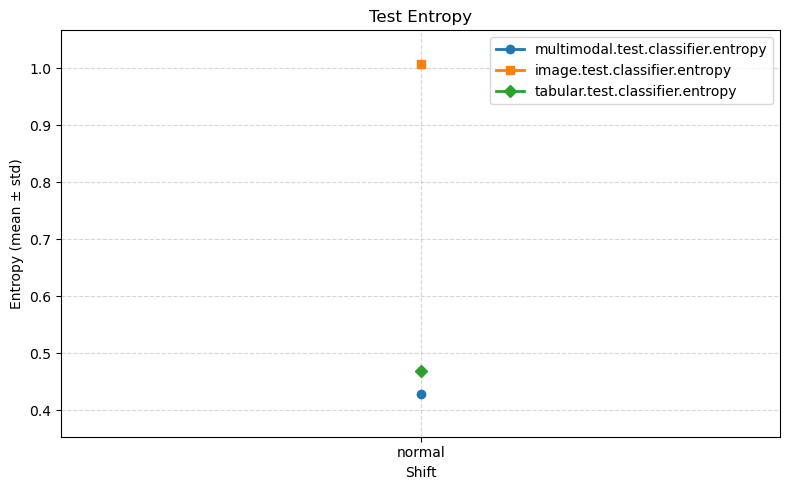

In [17]:
plot_one_grouped_df(summed_df_baseline_test, metrics=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Test Entropy", metric_name="Entropy")

In [18]:
summed_df_baseline_test

multimodal.test.classifier.entropy          \
                                     mean     std   
Shift                                               
normal                           0.428167  0.0422   

       image.test.classifier.entropy            \
                                mean       std   
Shift                                            
normal                        1.0082  0.026096   

       tabular.test.classifier.entropy           multimodal.test.balanced_acc  \
                                  mean       std                         mean   
Shift                                                                           
normal                        0.468269  0.038924                     0.750657   

                 image.test.balanced_acc            ... test.acc_imaging       \
             std                    mean       std  ...             mean  std   
Shift                                               ...                         
normal  0.011768                     0.6  0.328244  ...         0.493333  0.0   

       test.auc_imaging           test.acc_tabular           test.auc_tabular  \
                   mean       std             mean       std             mean   
Shift                                                                           
normal         0.550272  0.028522           0.8408  0.009704         0.908031   

                 Seed       
             std mean  std  
Shift                       
normal  0.004674  inf  0.0  

[1 rows x 32 columns]

In [19]:
summed_df_baseline_test["test.acc"]

,mean,std
Shift,,
normal,0.839093,0.00695


In [20]:
baseline_path = os.path.join(BASE_PATH, "smaller_dataset/baseline")
df_baseline_eval = create_one_group_df(dir_path=baseline_path, filename="eval")
df_baseline_eval =  make_df_numeric(df=df_baseline_eval[["Shift", "multimodal.classifier.entropy", "image.classifier.entropy", "tabular.classifier.entropy", "classifier.multi.acc", "classifier.image.acc", "classifier.tab.acc", "multimodal.train.case1_ratio", "multimodal.train.case2_i_ratio", "multimodal.train.case2_t_ratio", "multimodal.train.case3_ratio"]])
summed_df_baseline_eval = summarize_df(df=df_baseline_eval, group_col="Shift")
summed_df_baseline_eval

multimodal.classifier.entropy           image.classifier.entropy  \
                                mean       std                     mean   
Shift                                                                     
TE                           0.57631  0.020011                  1.02581   
age                          0.52803  0.010485                  1.03490   
normal                       0.55597  0.004103                  1.04093   
weight                       0.55399  0.012868                  1.02716   

                 tabular.classifier.entropy           classifier.multi.acc  \
             std                       mean       std                 mean   
Shift                                                                        
TE      0.005789                    0.58821  0.018710              0.75895   
age     0.015370                    0.53323  0.019364              0.78243   
normal  0.001604                    0.56902  0.002199              0.76618   
weight  0.013888                    0.56079  0.017833              0.76480   

                 classifier.image.acc           classifier.tab.acc            \
             std                 mean       std               mean       std   
Shift                                                                          
TE      0.006508              0.48709  0.000601            0.76121  0.008292   
age     0.025493              0.46055  0.005453            0.77701  0.019963   
normal  0.004263              0.48281  0.003635            0.76711  0.002360   
weight  0.005666              0.48727  0.001170            0.76646  0.006717   

       multimodal.train.case1_ratio           multimodal.train.case2_i_ratio  \
                               mean       std                           mean   
Shift                                                                          
TE                          0.51830  0.012989                        0.02537   
age                         0.50094  0.009990                        0.02317   
normal                      0.49700  0.006235                        0.01850   
weight                      0.52641  0.021601                        0.01947   

                 multimodal.train.case2_t_ratio            \
             std                           mean       std   
Shift                                                       
TE      0.008804                        0.42779  0.004821   
age     0.007838                        0.45944  0.010239   
normal  0.004159                        0.46224  0.005801   
weight  0.007004                        0.43185  0.024652   

       multimodal.train.case3_ratio            
                               mean       std  
Shift                                          
TE                          0.02856  0.004137  
age                         0.01645  0.006353  
normal                      0.02224  0.003888  
weight                      0.02229  0.008437

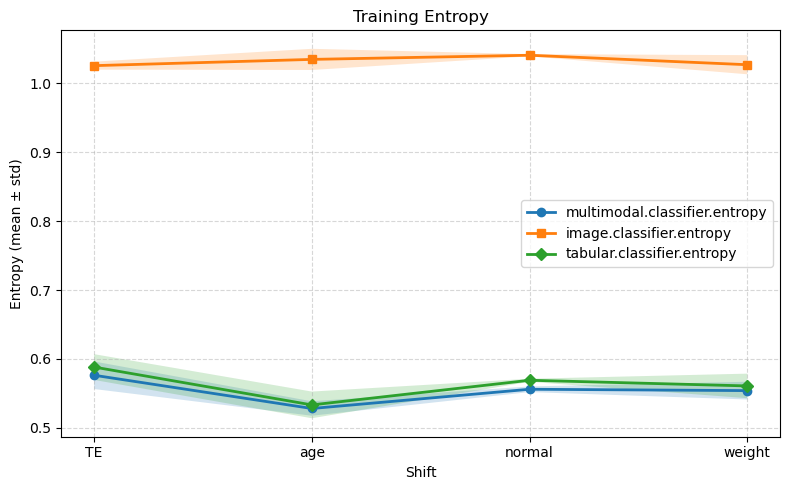

In [21]:
plot_one_grouped_df(summed_df_baseline_eval, metrics=["multimodal.classifier.entropy", "image.classifier.entropy", "tabular.classifier.entropy"], title="Training Entropy", metric_name="Entropy")

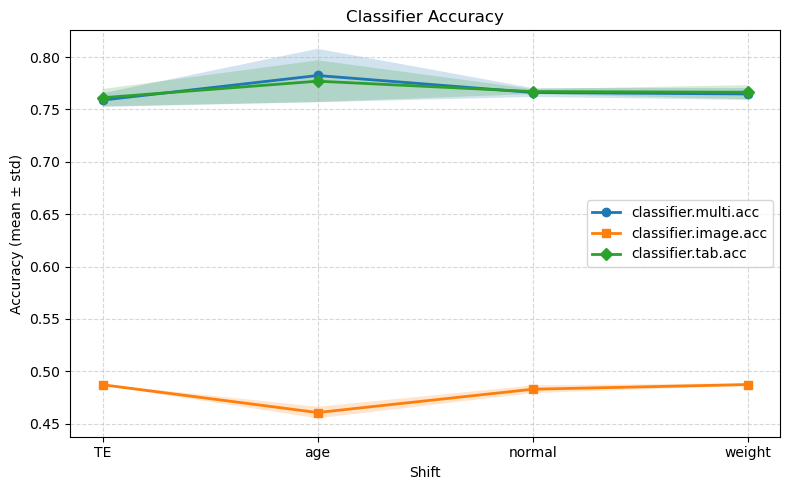

In [22]:
plot_one_grouped_df(summed_df_baseline_eval, metrics=["classifier.multi.acc", "classifier.image.acc", "classifier.tab.acc"], title="Classifier Accuracy", metric_name="Accuracy")

In [23]:
summed_df_baseline_eval[["multimodal.train.case1_ratio", "multimodal.train.case2_i_ratio", "multimodal.train.case2_t_ratio", "multimodal.train.case3_ratio"]]

multimodal.train.case1_ratio           multimodal.train.case2_i_ratio  \
                               mean       std                           mean   
Shift                                                                          
TE                          0.51830  0.012989                        0.02537   
age                         0.50094  0.009990                        0.02317   
normal                      0.49700  0.006235                        0.01850   
weight                      0.52641  0.021601                        0.01947   

                 multimodal.train.case2_t_ratio            \
             std                           mean       std   
Shift                                                       
TE      0.008804                        0.42779  0.004821   
age     0.007838                        0.45944  0.010239   
normal  0.004159                        0.46224  0.005801   
weight  0.007004                        0.43185  0.024652   

       multimodal.train.case3_ratio            
                               mean       std  
Shift                                          
TE                          0.02856  0.004137  
age                         0.01645  0.006353  
normal                      0.02224  0.003888  
weight                      0.02229  0.008437

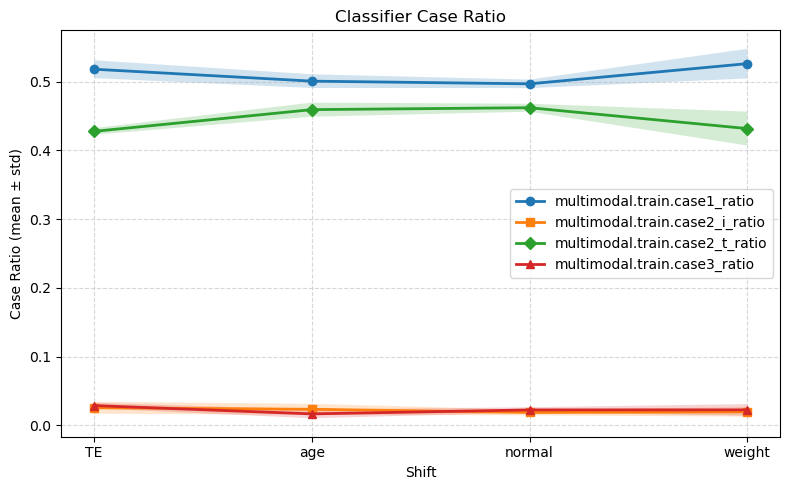

In [24]:
plot_one_grouped_df(summed_df_baseline_eval, metrics=["multimodal.train.case1_ratio", "multimodal.train.case2_i_ratio", "multimodal.train.case2_t_ratio", "multimodal.train.case3_ratio"], title="Classifier Case Ratio", metric_name="Case Ratio")

## Trainable Consent

### Keep all Embedding parts & contribute to classifier loss

#### Loss

$$
\mathcal{L} = \alpha \left(\mathcal{L}_{ce}(y_{m}, y) + \mathcal{L}_{ce}(y_{i}, y) + \mathcal{L}_{ce}(y_{t}, y)\right)+ \beta \left(\mathcal{L}_{CLIP}(feat_{i}, feat_{t})\right) + \gamma \left(\mathcal{L}^{i}_{ds} + \mathcal{L}^{t}_{ds}\right) + \epsilon \left( \mathcal{L}_{ce}(y^{*}, y) \right)
$$

where:

- $\mathcal{L}_{ce} = \text{Cross-Entropy Loss}$
- $\mathcal{L}_{CLIP} = \text{CLIP Loss}$
- $\mathcal{L}_{ds} = \text{CLUB Loss}$
- $\alpha = 0.2$ 
- $\beta = 3.0$ 
- $\gamma = 0.5$ 
- $\epsilon = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0]$

In [25]:
consent_path = os.path.join(BASE_PATH, "smaller_dataset/train_consent")
group_col = "epsilon"
df_c = create_two_group_df(dir_path=consent_path, filename="test", group_col=group_col, exp_name="consent")
summed_c_df = summarize_two_groups_df(df=df_c, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
normal,0.839093,0.00695


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


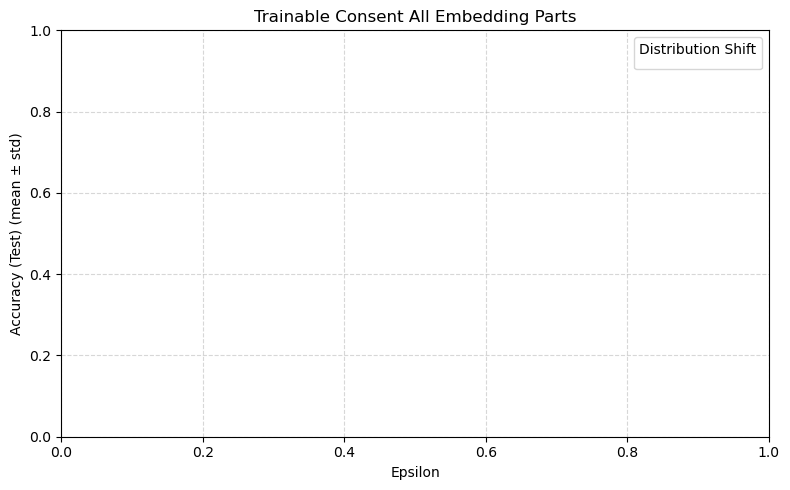

In [26]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Trainable Consent All Embedding Parts")

### Only keep refined Embeddings & contribute to classifier loss

In [27]:
refined_path = os.path.join(BASE_PATH, "smaller_dataset/train_consent_cut")
group_col = "epsilon"
df_c_keep = create_two_group_df(dir_path=refined_path, filename="test", group_col=group_col, exp_name="consent")
summed_c_keep_df = summarize_two_groups_df(df=df_c_keep, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
normal,0.839093,0.00695


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


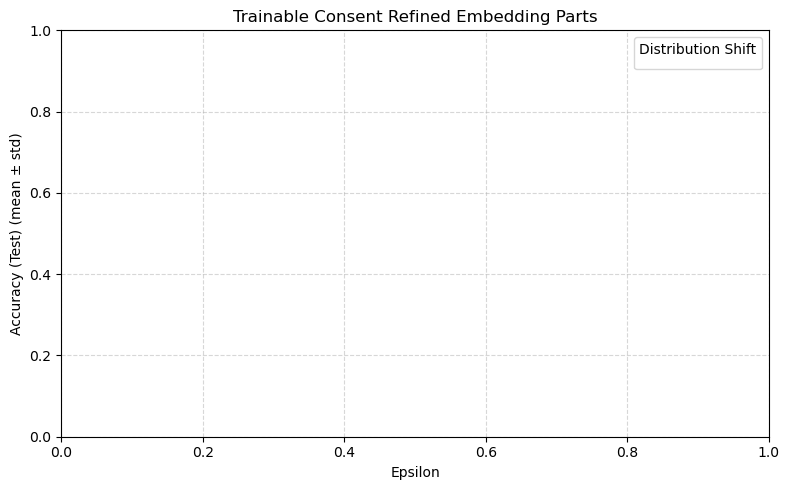

In [28]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_keep_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Trainable Consent Refined Embedding Parts")

### Keep all Embedding parts & Replace CE Classifier Loss

$$
\mathcal{L} = \beta \left(\mathcal{L}_{CLIP}(feat_{i}, feat_{t})\right) + \gamma \left(\mathcal{L}^{i}_{ds} + \mathcal{L}^{t}_{ds}\right) + \epsilon \left( \mathcal{L}_{ce}(y^{*}, y) \right)
$$

where:

- $\mathcal{L}_{ce} = \text{Cross-Entropy Loss}$
- $\mathcal{L}_{CLIP} = \text{CLIP Loss}$
- $\mathcal{L}_{ds} = \text{CLUB Loss}$
- $\beta = 3.0$ 
- $\gamma = 0.5$ 
- $\epsilon = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0]$

In [29]:
loss_path = os.path.join(BASE_PATH, "smaller_dataset/train_consent_loss")
group_col = "epsilon"
df_c_loss = create_two_group_df(dir_path=loss_path, filename="test", group_col=group_col, exp_name="consent")
summed_c_loss_df = summarize_two_groups_df(df=df_c_loss, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
normal,0.839093,0.00695


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


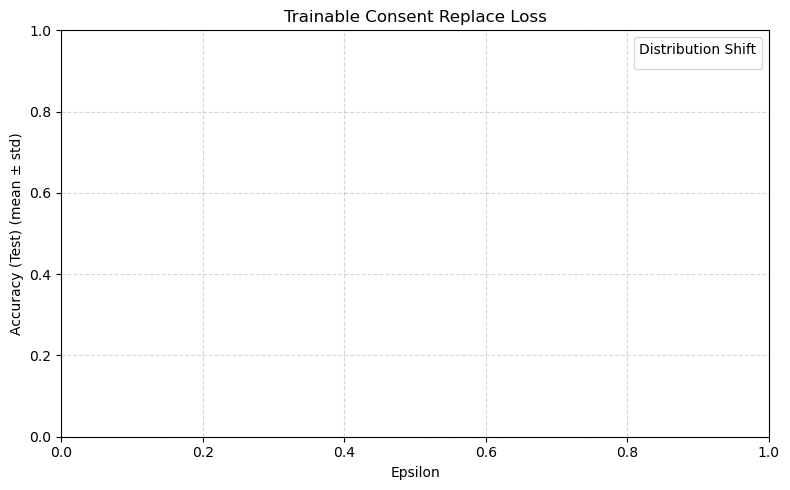

In [30]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_loss_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Trainable Consent Replace Loss")

## Mixture of Experts

#### Loss

$$
\mathcal{L} = \alpha \left(\mathcal{L}_{ce}(y_{m}, y) + \mathcal{L}_{ce}(y_{i}, y) + \mathcal{L}_{ce}(y_{t}, y)\right)+ \beta \left(\mathcal{L}_{CLIP}(feat_{i}, feat_{t})\right) + \gamma \left(\mathcal{L}^{i}_{ds} + \mathcal{L}^{t}_{ds}\right) + \epsilon \left( \mathcal{L}_{MoE}(y^{*}, y) + \mathcal{L}_{ce}(y^{*}, y)\right)
$$

where:

- $\mathcal{L}_{ce} = \text{Cross-Entropy Loss}$
- $\mathcal{L}_{CLIP} = \text{CLIP Loss}$
- $\mathcal{L}_{ds} = \text{CLUB Loss}$
- $\mathcal{L}_{MoE} = \text{Load Balancing Loss}$
- $\alpha = 0.2$ 
- $\beta = 3.0$ 
- $\gamma = 0.5$ 
- $\epsilon = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0]$

#### Classifier Input

- Gate: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Multimodal: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Imaging: $\mathcal{z}^{i}_{c}$
- Tabular: $\mathcal{z}^{t}_{c}$

#### k = 1

In [31]:
moe_path = os.path.join(BASE_PATH, "smaller_dataset/MoE_1_cut")
group_col = "epsilon"
df_c_moe = create_two_group_df(dir_path=moe_path, filename="test", group_col=group_col, exp_name="MoE")
summed_c_moe_df = summarize_two_groups_df(df=df_c_moe, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
normal,0.839093,0.00695


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


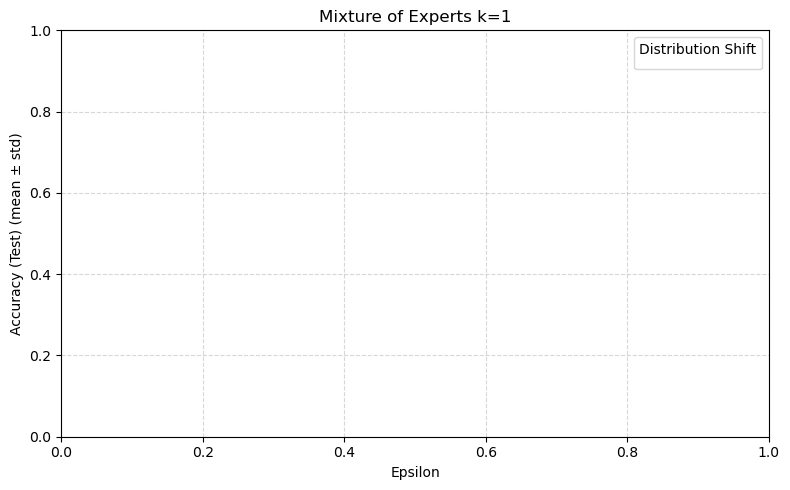

In [32]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_moe_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Mixture of Experts k=1")

#### k = 2

In [33]:
moe_2_path = os.path.join(BASE_PATH, "smaller_dataset/MoE_2_cut")
group_col = "epsilon"
df_c_moe_2 = create_two_group_df(dir_path=moe_2_path, filename="test", group_col=group_col, exp_name="MoE")
summed_c_moe_2_df = summarize_two_groups_df(df=df_c_moe_2, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
normal,0.839093,0.00695


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


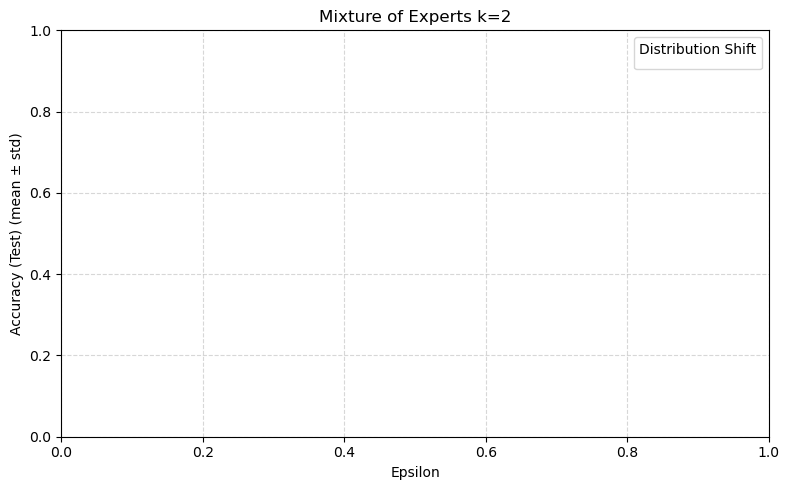

In [34]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_moe_2_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Mixture of Experts k=2")

#### k = 3


In [35]:
moe_3_path = os.path.join(BASE_PATH, "smaller_dataset/MoE_3_cut")
group_col = "epsilon"
df_c_moe_3 = create_two_group_df(dir_path=moe_3_path, filename="test", group_col=group_col, exp_name="MoE")
summed_c_moe_3_df = summarize_two_groups_df(df=df_c_moe_3, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
normal,0.839093,0.00695


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


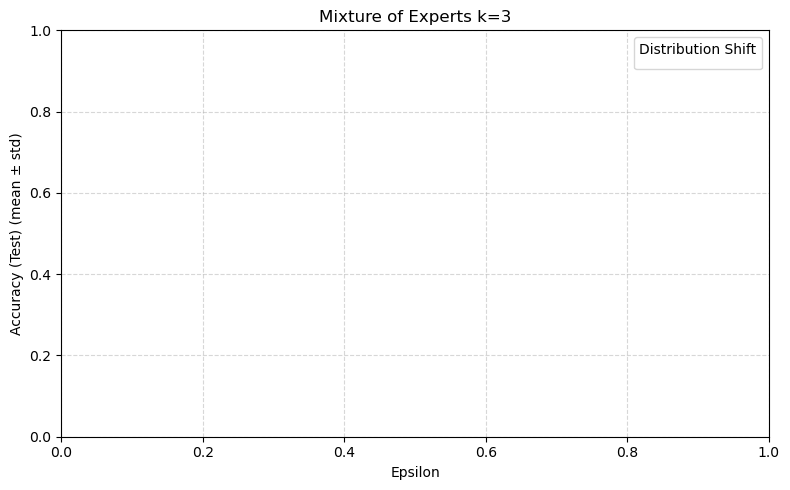

In [36]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_moe_3_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Mixture of Experts k=3")

#### Classifier Input

- Gate: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Multimodal: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Imaging: $\mathcal{z}^{i}_{c} + \mathcal{z}^{i}_{s}$
- Tabular: $\mathcal{z}^{t}_{c} + \mathcal{z}^{t}_{s}$

#### k = 1

## Bigger Dataset (removed GDTOTAL)

### Baseline

In [37]:
nogd_b_path = os.path.join(BASE_PATH, "smaller_dataset/batch_size_no_GDTOTAL")
group_col = "epsilon"
df_c_nogd_b = create_one_group_df(dir_path=nogd_b_path, filename="test", batchsize=True)
#summed_c_nogd_b_df = summarize_df(df=df_c_nogd_b, group_col="BatchSize")
#summed_c_nogd_b_df

In [38]:
#summed_c_nogd_b_df[["test.acc", "test.balanced_acc"]]

## Final Dataset

In [39]:
import re

def format_latex_table(raw: str) -> str:
    lines = raw.strip().splitlines()

    data_rows = []
    for line in lines:
        line = line.strip()

        # Match data rows like: 32 & 0.8409 $\pm$ 0.0015 & ...
        match = re.match(
            r"(\d+)\s*&\s*([\d.]+)\s*\\pm\s*([\d.]+)\s*&\s*([\d.]+)\s*\\pm\s*([\d.]+)",
            line
        )
        if match:
            bs, acc, acc_std, bal, bal_std = match.groups()

            row = (
                f"{bs} & "
                f"{float(acc):.4f} $\\pm$ {float(acc_std):.3f} & "
                f"{float(bal):.4f} $\\pm$ {float(bal_std):.3f} \\\\"
            )
            data_rows.append(row)

    table = [
        r"\begin{table}",
        r"\centering",
        r"\begin{tabular}{lll}",
        r"\hline",
        r"Batch Size & Accuracy & Balanced Accuracy \\",
        r"\hline",
        *data_rows,
        r"\hline",
        r"\end{tabular}",
        r"\end{table}",
    ]

    return "\n".join(table)

In [40]:
def convert_to_latex(df: pd.DataFrame):
    df_fmt = df.copy()
    df_fmt[("test.acc", "mean")] = (
        df[("test.acc", "mean")].map("{:.4f}".format)
        + " $\\pm$ "
        + df[("test.acc", "std")].map("{:.4f}".format)
    )
    
    df_fmt[("test.balanced_acc", "mean")] = (
        df[("test.balanced_acc", "mean")].map("{:.4f}".format)
        + " $\\pm$ "
        + df[("test.balanced_acc", "std")].map("{:.4f}".format)
    )
    
    df_final = df_fmt.drop(columns=[
        ("test.acc", "std"),
        ("test.balanced_acc", "std")
    ])
    
    print(df_final.to_latex(escape=False))

### Batchsize

In [41]:
f_batch_path = os.path.join(BASE_PATH, "final_dataset/baseline")
group_col = "epsilon"
df_c_f_batch = create_one_group_df(dir_path=f_batch_path, filename="test", batchsize=True, one_per_seed=True)
#display(df_c_f_batch)
df_c_f_batch["BatchSize"] = pd.to_numeric(df_c_f_batch["BatchSize"], errors='coerce')
summed_f_batch_df = summarize_df(df=df_c_f_batch, group_col="BatchSize")
summed_f_batch_df[["test.acc", "test.balanced_acc"]]

/tmp/ipykernel_1886200/1263068295.py:7: FutureWarning: ['Shift'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])


test.acc           test.balanced_acc          
               mean       std              mean       std
BatchSize                                                
32         0.840889  0.001540          0.757470  0.012946
64         0.841778  0.005551          0.752569  0.012038
128        0.842667  0.002667          0.751483  0.006917
256        0.845333  0.003771          0.756859  0.009402

In [42]:
f_batch_path = os.path.join(BASE_PATH, "final_dataset/baseline")
group_col = "epsilon"
df_c_f_batch_val = create_one_group_df(dir_path=f_batch_path, filename="eval", batchsize=True, one_per_seed=True)
#display(df_c_f_batch)
df_c_f_batch_val["BatchSize"] = pd.to_numeric(df_c_f_batch_val["BatchSize"], errors='coerce')
summed_f_batch_df_val = summarize_df(df=df_c_f_batch_val, group_col="BatchSize")
summed_f_batch_df_val[["eval.val.acc", "eval.val.balanced_acc"]]

/tmp/ipykernel_1886200/1263068295.py:7: FutureWarning: ['Shift'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])


eval.val.acc           eval.val.balanced_acc          
                  mean       std                  mean       std
BatchSize                                                       
32            0.831133  0.010108                0.7939  0.017112
64            0.827533  0.005564                0.7745  0.021496
128           0.836433  0.008140                0.7855  0.009334
256           0.822650  0.001909                0.7641       NaN

In [43]:
convert_to_latex(df=summed_f_batch_df[["test.acc", "test.balanced_acc"]])

\begin{tabular}{lll}
\toprule
{} &             test.acc &    test.balanced_acc \\
{} &                 mean &                 mean \\
BatchSize &                      &                      \\
\midrule
32        &  0.8409 $\pm$ 0.0015 &  0.7575 $\pm$ 0.0129 \\
64        &  0.8418 $\pm$ 0.0056 &  0.7526 $\pm$ 0.0120 \\
128       &  0.8427 $\pm$ 0.0027 &  0.7515 $\pm$ 0.0069 \\
256       &  0.8453 $\pm$ 0.0038 &  0.7569 $\pm$ 0.0094 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_1886200/1891150706.py:20: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_final.to_latex(escape=False))


### Baseline

In [44]:
f_base_path = os.path.join(BASE_PATH, "final_dataset/batchsize")
group_col = "epsilon"
df_c_f_base = create_one_group_df(dir_path=f_base_path, filename="test", one_per_seed=True)
display(df_c_f_base["Shift"].value_counts())
summed_f_base_df = summarize_df(df=df_c_f_base, group_col="Shift")
summed_f_base_df[["test.acc", "test.balanced_acc"]]

age       3
weight    3
TE        3
normal    3
Name: Shift, dtype: int64

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [53]:
def plot_results(path: str, group_col: str, filename: str, second_group_col: str, exp_name: str, metric: Union[str, list[str]], title: str, moe:bool = True, pattern: str = r"{exp_name}_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_)?([a-zA-Z]+)_final_seed", base_path:str=BASE_PATH, just_plot=False):
    moe_path = os.path.join(base_path, path)
    df_c_moe = create_two_group_df(dir_path=moe_path, filename=filename, group_col=group_col, exp_name=exp_name, pattern=pattern)
    #display(df_c_moe)
    summed_c_moe_df = summarize_two_groups_df(df=df_c_moe, first_group_col=group_col, second_group_col=second_group_col)
    moe_cols = [c for c in summed_c_moe_df.columns if str(c[0]).startswith('MoE.test.weight') or str(c[0]) in [group_col, second_group_col]]
    
    if moe_cols and moe:
        moe_cols = [c for c in summed_c_moe_df.columns if str(c[0]).startswith('MoE.test.weight')]
        moe_mean_cols = summed_c_moe_df[moe_cols].xs('mean', axis=1, level=1)

        # Prepare a DataFrame to collect max rows
        max_rows = pd.DataFrame()
        extra_cols = [('Shift', ''), ('epsilon', '')]

        # Iterate over shifts
        for shift, group_df in summed_c_moe_df.groupby(('Shift', '')):
            if not just_plot:
                print(f"\nShift: {shift}")
            for col in moe_mean_cols.columns:
                max_val = group_df[col]['mean'].max()  # max value for this weight in this shift
                rows = group_df[group_df[col]['mean'] == max_val]  # rows reaching the max
                if not just_plot:
                    print(f"{col} max value: {max_val}")
                #display(rows)
                # Optionally collect all rows
                max_rows = pd.concat([max_rows, rows])
        if not just_plot:
            display(max_rows[extra_cols + moe_cols])
        #display(summed_c_moe_df[extra_cols + moe_cols])

    metric_list = metric if isinstance(metric, list) else  [metric]
    for met in metric_list:
        met_name = MET_DICT[met]
        t = title + f" [{met_name}]"
        plot_two_grouped_df(df=summed_c_moe_df, first_group_col=group_col, second_group_col=second_group_col, metric=met, title=t)
    
    if isinstance(metric, list):
        cols = [group_col, second_group_col] + metric
    else:
        cols = [group_col, second_group_col]
        
    if filename == "test":
        cols += ["test.acc", "test.balanced_acc"]
    if filename == "eval":
        cols += ["eval.val.acc", "val.balanced_acc"]       
        
    display(summed_c_moe_df[cols])
    
    moe_cols = ["test.balanced_acc"] if filename == "test" else ["val.balanced_acc"]
    moe_mean_cols = summed_c_moe_df[moe_cols].xs('mean', axis=1, level=1)
    # Prepare a DataFrame to collect max rows
    max_rows = pd.DataFrame()
    extra_cols = [('Shift', ''), ('epsilon', '')]
    # Iterate over shifts
    for shift, group_df in summed_c_moe_df.groupby(('Shift', '')):
        for col in moe_mean_cols.columns:
            max_val = group_df[col]['mean'].max()  # max value for this weight in this shift
            rows = group_df[group_df[col]['mean'] == max_val]  # rows reaching the max
            #display(rows)
            # Optionally collect all rows
            max_rows = pd.concat([max_rows, rows])
    if filename == "test":
        metric_cols = [('test.acc', 'mean'), ('test.acc', 'std'), ('test.balanced_acc', 'mean'), ('test.balanced_acc', 'std')]
    else:
        metric_cols = [('eval.val.acc', 'mean'), ('eval.val.acc', 'std'), ("val.balanced_acc", 'mean'), ("val.balanced_acc", 'std')]
    display(max_rows[extra_cols + metric_cols])
    display(summed_f_base_df[["test.acc", "test.balanced_acc"]])

In [46]:
metric = ["test.balanced_acc"]

In [47]:
summed_f_base_df[["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy", "test.acc", "test.balanced_acc"]]  

multimodal.test.classifier.entropy            \
                                     mean       std   
Shift                                                 
TE                               0.451688  0.005861   
age                              0.548849  0.029364   
normal                           0.458434  0.073259   
weight                           0.502436  0.045353   

       image.test.classifier.entropy            \
                                mean       std   
Shift                                            
TE                          1.016213  0.034405   
age                         0.977101  0.004334   
normal                      1.030628  0.038214   
weight                      1.000474  0.020076   

       tabular.test.classifier.entropy            test.acc            \
                                  mean       std      mean       std   
Shift                                                                  
TE                            0.488810  0.023102  0.852444  0.009365   
age                           0.583696  0.033005  0.818667  0.016000   
normal                        0.497962  0.062017  0.840000  0.002667   
weight                        0.548109  0.068495  0.854222  0.007698   

       test.balanced_acc            
                    mean       std  
Shift                               
TE              0.819313  0.012563  
age             0.818361  0.009531  
normal          0.752783  0.004264  
weight          0.841267  0.022204

In [48]:
def create_loss_df(dir_path: str, filename: str, group_col: str, exp_name: str, metric: str, pattern=r"{exp_name}_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_)?([a-zA-Z]+)_final_seed") -> pd.DataFrame:
    df = pd.DataFrame()
    # Escape curly braces that belong to the regex (not the format string)
    pattern = pattern.format(exp_name=re.escape(exp_name))
    pattern = re.compile(pattern)

    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue
        subdir_files = os.listdir(subdir_path)
        if not {"train_loss_metrics.csv", "val_loss_metrics.csv"}.issubset(subdir_files):
            continue

        # extract number and word after "consent_"
        match = pattern.search(subdir)
        consent_num, consent_label = (None, None)
        if match:
            consent_num = match.group(1)
            consent_label = match.group(2)

        for file in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue

            #print(file_path)
            file_df = pd.read_csv(file_path)[[metric]].copy()
            
            # Add epsilon (group_col) and shift
            file_df[group_col] = consent_num
            file_df["Shift"] = consent_label

            # Create MultiIndex: top = shift, middle = epsilon, bottom = metric
            multi_cols = pd.MultiIndex.from_tuples([(consent_label, consent_num, metric)])

            multi_file_df = pd.DataFrame(file_df[metric].values, columns=multi_cols)

            # Concatenate horizontally into master df
            if df.empty:
                df = multi_file_df
            else:
                df = pd.concat([df, multi_file_df], axis=1)

    return df

In [49]:
import matplotlib.cm as cm

def plot_loss_curves(path: str, group_col: str, exp_name: str, metric: str, plot_split : str, epsilon=None, shift=None, pattern: str = r"{exp_name}_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_)?([a-zA-Z]+)_final_seed", base_path:str=BASE_PATH):
    moe_path = os.path.join(base_path, path)
    df_c_moe_train = create_loss_df(dir_path=moe_path, filename="train_loss_metrics", group_col=group_col, exp_name=exp_name, pattern=pattern, metric=metric)
    df_c_moe_val = create_loss_df(dir_path=moe_path, filename="val_loss_metrics", group_col=group_col, exp_name=exp_name, pattern=pattern, metric=metric.replace("train", "val"))
    df_agg_train = df_c_moe_train.groupby(level=[0, 1], axis=1).mean()
    df_agg_val = df_c_moe_val.groupby(level=[0, 1], axis=1).mean()
    if epsilon:
        df_agg_train = df_agg_train.xs(key=str(epsilon), level=1, axis=1)
        df_agg_val = df_agg_val.xs(key=str(epsilon), level=1, axis=1)
    if shift:
        df_agg_train = df_agg_train.xs(key=str(shift), level=0, axis=1)
        df_agg_val = df_agg_val.xs(key=str(shift), level=0, axis=1)
    
    display(df_agg_train)
    display(df_agg_val)

    df_plot_train = df_agg_train.copy()
    if isinstance(df_plot_train.columns, pd.MultiIndex):
        df_plot_train.columns = ['_'.join(map(str, col)) for col in df_plot_train.columns]
    else:
        df_plot_train.columns = df_plot_train.columns
    
    df_plot_val = df_agg_val.copy()
    if isinstance(df_plot_val.columns, pd.MultiIndex):
        df_plot_val.columns = ['_'.join(map(str, col)) for col in df_plot_val.columns]
    else:
        df_plot_val.columns = df_plot_val.columns    
    
    # Create color maps for unique colors
    cmap_train = cm.get_cmap('tab20', len(df_plot_train.columns))
    cmap_val = cm.get_cmap('tab20', len(df_plot_val.columns))

    plt.figure(figsize=(12, 6))

    # Plot train curves
    if plot_split == "train" or plot_split == "all":
        for i, col in enumerate(df_plot_train.columns):
            plt.plot(df_plot_train.index, df_plot_train[col], color=cmap_train(i), linestyle='-', label=f"Train: {col}")

    # Plot val curves
    if plot_split == "val" or plot_split == "all":
        for i, col in enumerate(df_plot_val.columns):
            plt.plot(df_plot_val.index, df_plot_val[col], color=cmap_val(i), linestyle='--', label=f"Val: {col}")

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title("Loss curves by shift/metric")
    plt.legend(ncol=2, fontsize=8)  # optional: make legend smaller or multi-column
    plt.show()

TE                                                    age  \
           0.1        0.5          1          2          3        0.1   
0    50.953557  51.459536  52.091850  53.356244  54.620817  50.956496   
1    19.629882  20.085851  20.651019  21.796870  22.927984  19.633366   
2    11.896928  12.328045  12.858126  13.918948  14.964792  11.898108   
3    11.323413  11.691492  12.150343  13.055571  13.950365  11.336313   
4    11.140539  11.490070  11.928838  12.790795  13.655869  11.146840   
..         ...        ...        ...        ...        ...        ...   
193        NaN        NaN        NaN        NaN        NaN        NaN   
194        NaN        NaN        NaN        NaN        NaN        NaN   
195        NaN        NaN        NaN        NaN        NaN        NaN   
196        NaN        NaN        NaN        NaN        NaN        NaN   
197        NaN        NaN        NaN        NaN        NaN        NaN   

                                                    normal             \
           0.5          1          2          3        0.1        0.5   
0    51.463226  52.096536  53.363525  54.630280  51.144707  51.652968   
1    20.091412  20.663280  21.814696  22.969970  19.654926  20.114838   
2    12.320590  12.841698  13.884008  14.912112  11.908211  12.333475   
3    11.714608  12.186562  13.107066  14.033825  11.325640  11.696625   
4    11.495027  11.937107  12.801632  13.678916  11.133586  11.481372   
..         ...        ...        ...        ...        ...        ...   
193        NaN        NaN        NaN        NaN        NaN        NaN   
194        NaN        NaN        NaN        NaN        NaN        NaN   
195        NaN        NaN        NaN        NaN        NaN        NaN   
196        NaN        NaN        NaN        NaN        NaN        NaN   
197        NaN        NaN        NaN        NaN        NaN        NaN   

                                         weight                        \
             1          2          3        0.1        0.5          1   
0    52.288073  53.558879  54.829522  50.877912  51.388461  52.027014   
1    20.688769  21.844333  23.006620  19.640690  20.104720  20.684804   
2    12.869144  13.918538  14.956334  11.900010  12.330369  12.865055   
3    12.154145  13.059996  13.961251  11.342774  11.727902  12.203147   
4    11.914100  12.771142  13.640792  11.149584  11.505382  11.943947   
..         ...        ...        ...        ...        ...        ...   
193        NaN  12.050207  12.725460        NaN        NaN        NaN   
194        NaN  12.095093  12.784927        NaN        NaN        NaN   
195        NaN  12.120642  12.769810        NaN        NaN        NaN   
196        NaN  12.097976  12.772117        NaN        NaN        NaN   
197        NaN  12.067513  12.680449        NaN        NaN        NaN   

                           
             2          3  
0    53.303624  54.579510  
1    21.843432  22.996924  
2    13.917418  14.952131  
3    13.140759  14.048569  
4    12.817529  13.674251  
..         ...        ...  
193        NaN        NaN  
194        NaN        NaN  
195        NaN        NaN  
196        NaN        NaN  
197        NaN        NaN  

[198 rows x 20 columns]

TE                                                         age  \
            0.1         0.5           1           2           3         0.1   
0    304.663188  305.186717  305.920319  307.336283  308.718369  296.779317   
1     38.030533   38.548164   39.194373   40.487794   41.781237   37.983887   
2     12.357531   12.816304   13.377594   14.497836   15.637271   12.353898   
3     11.399601   11.798849   12.291403   13.228349   14.142300   11.328259   
4     11.091866   11.416013   11.822224   12.624247   13.446519   11.050215   
..          ...         ...         ...         ...         ...         ...   
194         NaN         NaN         NaN         NaN         NaN         NaN   
195         NaN         NaN         NaN         NaN         NaN         NaN   
196         NaN         NaN         NaN         NaN         NaN         NaN   
197         NaN         NaN         NaN         NaN         NaN         NaN   
198         NaN         NaN         NaN         NaN         NaN         NaN   

                                                         normal              \
            0.5           1           2           3         0.1         0.5   
0    297.392527  298.126699  299.609431  301.068019  272.996933  273.547241   
1     38.501874   39.149447   40.444333   41.739297   38.027382   38.544416   
2     12.794293   13.349599   14.465067   15.558100   12.323346   12.766683   
3     11.681339   12.109571   12.937779   13.738069   11.354319   11.721206   
4     11.355184   11.718981   12.445724   13.166800   11.048786   11.353782   
..          ...         ...         ...         ...         ...         ...   
194         NaN         NaN         NaN         NaN         NaN         NaN   
195         NaN         NaN         NaN         NaN         NaN         NaN   
196         NaN         NaN         NaN         NaN         NaN         NaN   
197         NaN         NaN         NaN         NaN         NaN         NaN   
198         NaN         NaN         NaN         NaN         NaN         NaN   

                                             weight                          \
              1           2           3         0.1         0.5           1   
0    274.257980  275.668203  277.071726  286.844833  287.488622  288.194194   
1     39.190545   40.479987   41.771146   38.056838   38.583923   39.243018   
2     13.312396   14.430532   15.524241   12.354679   12.805394   13.364917   
3     12.165468   13.026639   13.871680   11.358235   11.724588   12.165555   
4     11.743591   12.505504   13.273251   11.079974   11.392969   11.771727   
..          ...         ...         ...         ...         ...         ...   
194         NaN   12.071971   12.803619         NaN         NaN         NaN   
195         NaN   12.158186   12.814731         NaN         NaN         NaN   
196         NaN   12.117439   12.767447         NaN         NaN         NaN   
197         NaN   12.052459   12.671594         NaN         NaN         NaN   
198         NaN   12.000466   12.748044         NaN         NaN         NaN   

                             
              2           3  
0    289.681157  291.147756  
1     40.560851   41.879027  
2     14.467191   15.573005  
3     13.027587   13.881674  
4     12.534441   13.250949  
..          ...         ...  
194         NaN         NaN  
195         NaN         NaN  
196         NaN         NaN  
197         NaN         NaN  
198         NaN         NaN  

[199 rows x 20 columns]

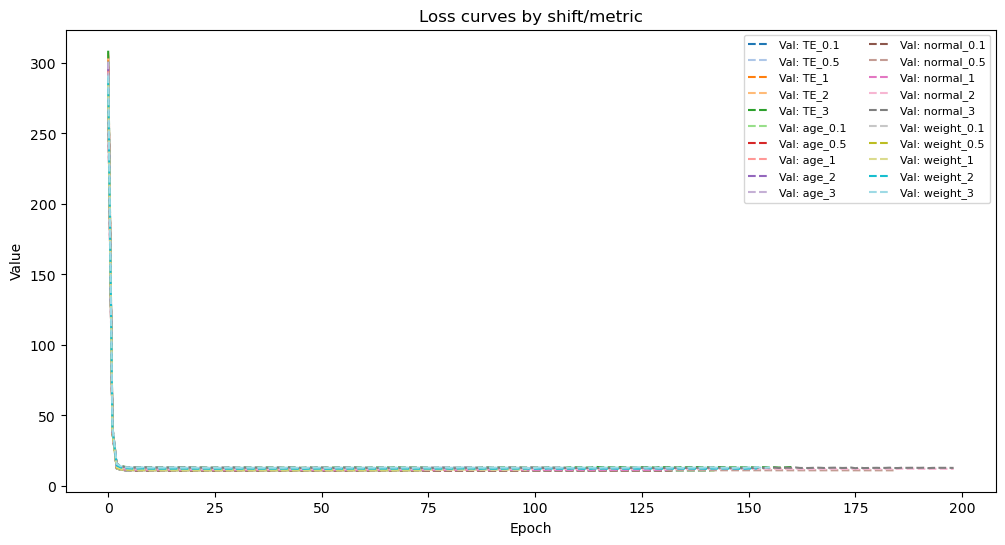

In [50]:
plot_loss_curves(path="final_dataset/MoE1-linear", group_col="epsilon", exp_name="MoE", metric="multimodal.train.loss", epsilon=None, shift=None, plot_split="val")#, base_path=BASE_DVM_PATH,pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

## MoE k=1 Linear


Shift: TE
MoE.test.weight0 max value: 0.5520000060399374
MoE.test.weight1 max value: 0.32711110264062876
MoE.test.weight2 max value: 0.4382222294807434

Shift: age
MoE.test.weight0 max value: 0.5795555512110392
MoE.test.weight1 max value: 0.19288888573646545
MoE.test.weight2 max value: 0.6275555690129598

Shift: normal
MoE.test.weight0 max value: 0.6088889042536417
MoE.test.weight1 max value: 0.33866667623321217
MoE.test.weight2 max value: 0.42577778299649555

Shift: weight
MoE.test.weight0 max value: 0.5244444410006205
MoE.test.weight1 max value: 0.09066666538516677
MoE.test.weight2 max value: 0.7271111011505127


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
12      TE       2         0.552000  0.100240         0.154667  0.242579   
8       TE       1         0.416889  0.270983         0.327111  0.466524   
0       TE     0.1         0.312889  0.267204         0.248889  0.401440   
1      age     0.1         0.579556  0.165942         0.018667  0.023702   
9      age       1         0.311111  0.238310         0.192889  0.265736   
5      age     0.5         0.326222  0.090876         0.046222  0.048099   
18  normal       3         0.608889  0.031251         0.080000  0.090784   
6   normal     0.5         0.334222  0.199810         0.338667  0.415316   
2   normal     0.1         0.266667  0.205645         0.307556  0.466738   
11  weight       1         0.524444  0.182766         0.085333  0.138590   
15  weight       2         0.310222  0.033342         0.090667  0.072000   
19  weight       3         0.219556  0.150952         0.053333  0.064056   

   MoE.test.weight2            
               mean       std  
12         0.293333  0.266306  
8          0.256000  0.230755  
0          0.438222  0.335982  
1          0.401778  0.158937  
9          0.496000  0.030753  
5          0.627556  0.072410  
18         0.311111  0.096234  
6          0.327111  0.292293  
2          0.425778  0.398328  
11         0.390222  0.295511  
15         0.599111  0.075629  
19         0.727111  0.166476

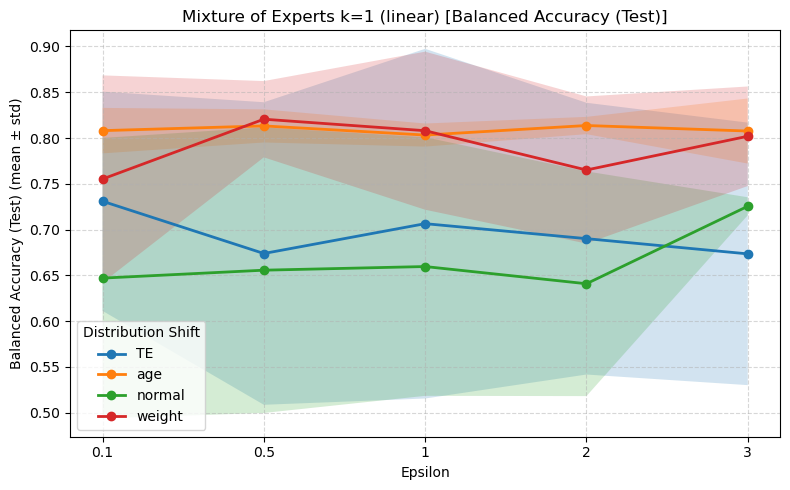

epsilon   Shift test.balanced_acc            test.acc            \
                                mean       std      mean       std   
0      0.1      TE          0.730988  0.119724  0.792889  0.100110   
1      0.1     age          0.808095  0.024830  0.804444  0.013422   
2      0.1  normal          0.647033  0.153062  0.732444  0.161026   
3      0.1  weight          0.755256  0.113205  0.814222  0.035511   
4      0.5      TE          0.673909  0.165227  0.749333  0.166277   
5      0.5     age          0.813264  0.018088  0.807111  0.004073   
6      0.5  normal          0.655688  0.155959  0.732444  0.160938   
7      0.5  weight          0.820591  0.041647  0.836444  0.015163   
8      1.0      TE          0.706503  0.190976  0.747556  0.174057   
9      1.0     age          0.803278  0.012595  0.795556  0.029973   
10     1.0  normal          0.659668  0.141228  0.726222  0.167477   
11     1.0  weight          0.808036  0.086298  0.834667  0.025716   
12     2.0      TE          0.690139  0.148413  0.735111  0.162127   
13     2.0     age          0.813694  0.009430  0.805333  0.018667   
14     2.0  normal          0.640888  0.122732  0.729778  0.131300   
15     2.0  weight          0.765109  0.080334  0.792889  0.041340   
16     3.0      TE          0.673501  0.143357  0.726222  0.168957   
17     3.0     age          0.807680  0.035531  0.773333  0.063498   
18     3.0  normal          0.725494  0.009841  0.796444  0.033976   
19     3.0  weight          0.801968  0.054363  0.781333  0.071901   

   test.balanced_acc            
                mean       std  
0           0.730988  0.119724  
1           0.808095  0.024830  
2           0.647033  0.153062  
3           0.755256  0.113205  
4           0.673909  0.165227  
5           0.813264  0.018088  
6           0.655688  0.155959  
7           0.820591  0.041647  
8           0.706503  0.190976  
9           0.803278  0.012595  
10          0.659668  0.141228  
11          0.808036  0.086298  
12          0.690139  0.148413  
13          0.813694  0.009430  
14          0.640888  0.122732  
15          0.765109  0.080334  
16          0.673501  0.143357  
17          0.807680  0.035531  
18          0.725494  0.009841  
19          0.801968  0.054363

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
0       TE     0.1  0.792889  0.100110          0.730988  0.119724
13     age     2.0  0.805333  0.018667          0.813694  0.009430
18  normal     3.0  0.796444  0.033976          0.725494  0.009841
7   weight     0.5  0.836444  0.015163          0.820591  0.041647

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [51]:
plot_results(path="final_dataset/MoE1-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=1 (linear)", just_plot=False)

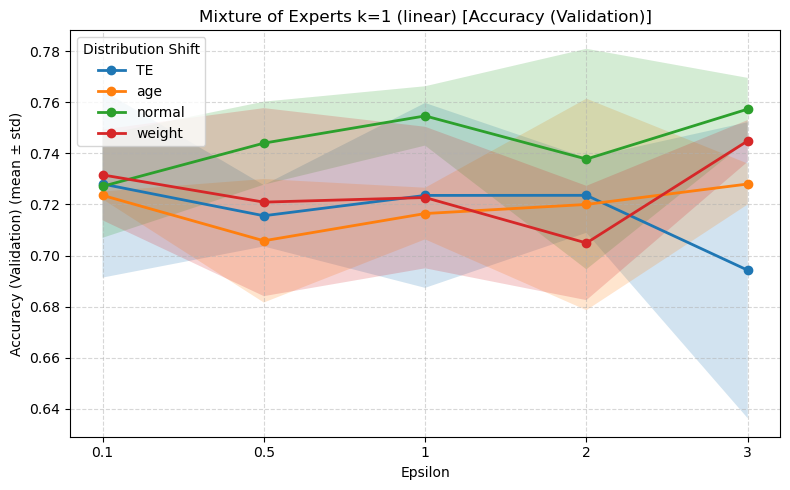

epsilon   Shift eval.val.acc           val.balanced_acc          
                           mean       std             mean       std
0      0.1      TE     0.728000  0.036661         0.660400  0.052170
1      0.1     age     0.723567  0.001501         0.661833  0.035650
2      0.1  normal     0.727100  0.020180         0.622533  0.021800
3      0.1  weight     0.731567  0.017770         0.644633  0.009996
4      0.5      TE     0.715567  0.012023         0.649033  0.029157
5      0.5     age     0.705767  0.024178         0.636900  0.029258
6      0.5  normal     0.744000  0.016251         0.651767  0.018058
7      0.5  weight     0.720900  0.036815         0.619933  0.036363
8      1.0      TE     0.723533  0.036207         0.642933  0.045671
9      1.0     age     0.716433  0.010108         0.657600  0.022431
10     1.0  normal     0.754667  0.011620         0.664000  0.009001
11     1.0  weight     0.722700  0.027713         0.644967  0.017127
12     2.0      TE     0.723567  0.014665         0.653400  0.012341
13     2.0     age     0.720000  0.041416         0.662367  0.022357
14     2.0  normal     0.737767  0.043181         0.651133  0.050593
15     2.0  weight     0.704900  0.022381         0.614033  0.030737
16     3.0      TE     0.694233  0.057970         0.627200  0.058052
17     3.0     age     0.728000  0.008000         0.656900  0.047403
18     3.0  normal     0.757333  0.012220         0.664533  0.021180
19     3.0  weight     0.744900  0.008150         0.662300  0.011131

Shift epsilon eval.val.acc           val.balanced_acc          
                           mean       std             mean       std
0       TE     0.1     0.728000  0.036661         0.660400  0.052170
13     age     2.0     0.720000  0.041416         0.662367  0.022357
18  normal     3.0     0.757333  0.012220         0.664533  0.021180
19  weight     3.0     0.744900  0.008150         0.662300  0.011131

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [54]:
plot_results(path="final_dataset/MoE1-linear", group_col="epsilon", filename="eval", exp_name="MoE", second_group_col="Shift", metric="eval.val.acc", moe=False, title="Mixture of Experts k=1 (linear)", just_plot=False)

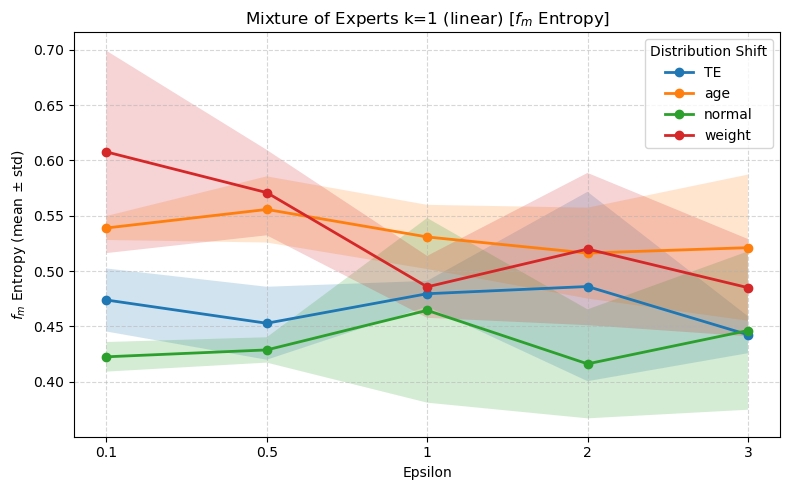

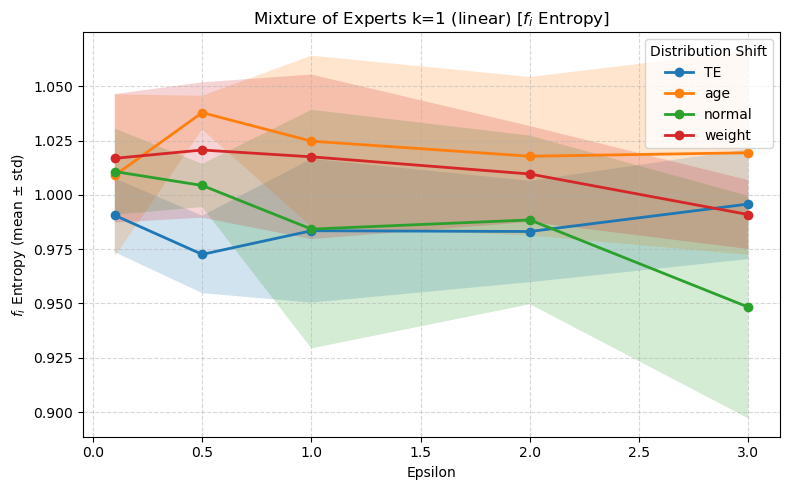

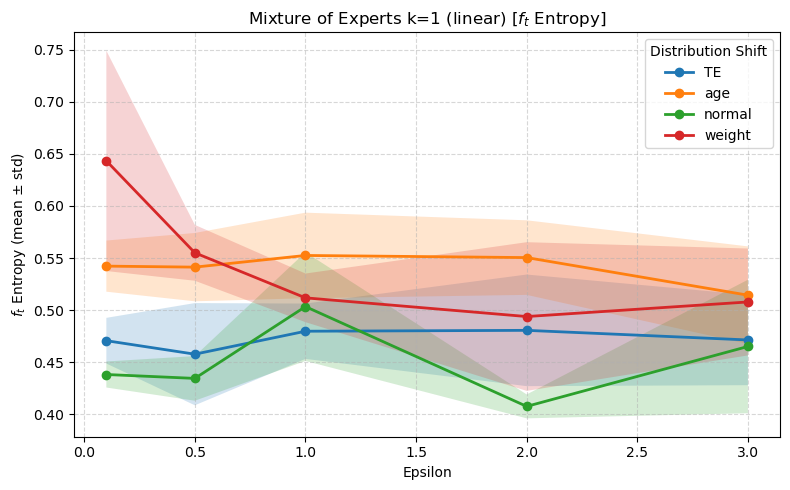

epsilon   Shift multimodal.test.classifier.entropy            \
                                                 mean       std   
0      0.1      TE                           0.473865  0.028484   
1      0.1     age                           0.538923  0.010813   
2      0.1  normal                           0.422530  0.013373   
3      0.1  weight                           0.607659  0.091422   
4      0.5      TE                           0.452857  0.032970   
5      0.5     age                           0.555681  0.029896   
6      0.5  normal                           0.428760  0.011475   
7      0.5  weight                           0.570902  0.038589   
8      1.0      TE                           0.479517  0.011601   
9      1.0     age                           0.530824  0.029014   
10     1.0  normal                           0.464508  0.083411   
11     1.0  weight                           0.485738  0.027981   
12     2.0      TE                           0.486045  0.085543   
13     2.0     age                           0.516232  0.041028   
14     2.0  normal                           0.416167  0.049228   
15     2.0  weight                           0.519888  0.068792   
16     3.0      TE                           0.442497  0.016716   
17     3.0     age                           0.521131  0.066030   
18     3.0  normal                           0.446262  0.071548   
19     3.0  weight                           0.485020  0.043948   

   image.test.classifier.entropy           tabular.test.classifier.entropy  \
                            mean       std                            mean   
0                       0.990559  0.016987                        0.470591   
1                       1.009015  0.037222                        0.542225   
2                       1.010718  0.019821                        0.438104   
3                       1.016818  0.029584                        0.643332   
4                       0.972603  0.017826                        0.457628   
5                       1.037843  0.007763                        0.541246   
6                       1.004328  0.009941                        0.434364   
7                       1.020648  0.031145                        0.555003   
8                       0.983491  0.033105                        0.479675   
9                       1.024721  0.039369                        0.552464   
10                      0.984244  0.054919                        0.503330   
11                      1.017509  0.037881                        0.511750   
12                      0.983138  0.023325                        0.480524   
13                      1.017784  0.036477                        0.550423   
14                      0.988469  0.038803                        0.407470   
15                      1.009604  0.022066                        0.493789   
16                      0.995777  0.025323                        0.471294   
17                      1.019377  0.046972                        0.514311   
18                      0.948323  0.051184                        0.465035   
19                      0.990936  0.015843                        0.507792   

              test.acc           test.balanced_acc            
         std      mean       std              mean       std  
0   0.021937  0.792889  0.100110          0.730988  0.119724  
1   0.024566  0.804444  0.013422          0.808095  0.024830  
2   0.012499  0.732444  0.161026          0.647033  0.153062  
3   0.105818  0.814222  0.035511          0.755256  0.113205  
4   0.049092  0.749333  0.166277          0.673909  0.165227  
5   0.032819  0.807111  0.004073          0.813264  0.018088  
6   0.021438  0.732444  0.160938          0.655688  0.155959  
7   0.026825  0.836444  0.015163          0.820591  0.041647  
8   0.026580  0.747556  0.174057          0.706503  0.190976  
9   0.041116  0.795556  0.029973          0.803278  0.012595  
10  0.052208  0.726222  0.167477          0.659668  0.1

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
0       TE     0.1  0.792889  0.100110          0.730988  0.119724
13     age     2.0  0.805333  0.018667          0.813694  0.009430
18  normal     3.0  0.796444  0.033976          0.725494  0.009841
7   weight     0.5  0.836444  0.015163          0.820591  0.041647

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [55]:
plot_results(path="final_dataset/MoE1-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=1 MLP


Shift: TE
MoE.test.weight0 max value: 0.5795555549363295
MoE.test.weight1 max value: 0.2977777767616014
MoE.test.weight2 max value: 0.3760000119606654

Shift: age
MoE.test.weight0 max value: 0.5724444488684336
MoE.test.weight1 max value: 0.36266666650772095
MoE.test.weight2 max value: 0.21688888718684507

Shift: normal
MoE.test.weight0 max value: 0.5484444499015808
MoE.test.weight1 max value: 0.2871111035346985
MoE.test.weight2 max value: 0.27466666636367637

Shift: weight
MoE.test.weight0 max value: 0.2711111133297284
MoE.test.weight1 max value: 0.21511110663414001
MoE.test.weight2 max value: 0.702222208182017


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
16      TE       3         0.579556  0.487091         0.297778  0.513459   
16      TE       3         0.579556  0.487091         0.297778  0.513459   
8       TE       1         0.497778  0.460758         0.126222  0.218623   
1      age     0.1         0.572444  0.408073         0.232000  0.203664   
13     age       2         0.423111  0.499602         0.362667  0.369514   
17     age       3         0.509333  0.420801         0.273778  0.306775   
2   normal     0.1         0.548444  0.501619         0.202667  0.178905   
18  normal       3         0.511111  0.458964         0.287111  0.260793   
10  normal       1         0.529778  0.468737         0.195556  0.169377   
19  weight       3         0.271111  0.368486         0.139556  0.122502   
7   weight     0.5         0.201778  0.342585         0.215111  0.193776   
11  weight       1         0.231111  0.400296         0.066667  0.075941   

   MoE.test.weight2            
               mean       std  
16         0.122667  0.083820  
16         0.122667  0.083820  
8          0.376000  0.267585  
1          0.195556  0.231345  
13         0.214222  0.267948  
17         0.216889  0.114055  
2          0.248889  0.417308  
18         0.201778  0.256088  
10         0.274667  0.375072  
19         0.589333  0.245985  
7          0.583111  0.163872  
11         0.702222  0.346095

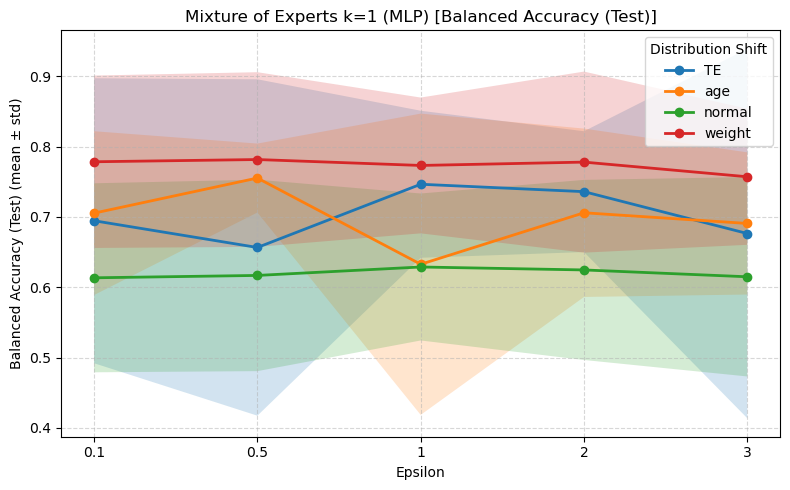

epsilon   Shift test.balanced_acc            test.acc            \
                                mean       std      mean       std   
0      0.1      TE          0.694545  0.202565  0.774222  0.127787   
1      0.1     age          0.705336  0.116453  0.775111  0.028514   
2      0.1  normal          0.613407  0.134351  0.707556  0.150291   
3      0.1  weight          0.778374  0.122540  0.827556  0.051731   
4      0.5      TE          0.656516  0.239138  0.741333  0.166619   
5      0.5     age          0.755239  0.048997  0.791111  0.009365   
6      0.5  normal          0.616780  0.136072  0.706667  0.145498   
7      0.5  weight          0.781551  0.124159  0.828444  0.050055   
8      1.0      TE          0.746405  0.104535  0.832889  0.033766   
9      1.0     age          0.632662  0.214160  0.754667  0.057007   
10     1.0  normal          0.628776  0.104472  0.742222  0.124575   
11     1.0  weight          0.773131  0.096527  0.821333  0.053930   
12     2.0      TE          0.735879  0.085878  0.835556  0.024197   
13     2.0     age          0.705872  0.119688  0.789333  0.028095   
14     2.0  normal          0.624584  0.128010  0.738667  0.138590   
15     2.0  weight          0.777894  0.128704  0.825778  0.050479   
16     3.0      TE          0.676353  0.262618  0.743111  0.168007   
17     3.0     age          0.690681  0.101051  0.737778  0.055575   
18     3.0  normal          0.614870  0.141730  0.710222  0.150904   
19     3.0  weight          0.757055  0.096732  0.828444  0.054802   

   test.balanced_acc            
                mean       std  
0           0.694545  0.202565  
1           0.705336  0.116453  
2           0.613407  0.134351  
3           0.778374  0.122540  
4           0.656516  0.239138  
5           0.755239  0.048997  
6           0.616780  0.136072  
7           0.781551  0.124159  
8           0.746405  0.104535  
9           0.632662  0.214160  
10          0.628776  0.104472  
11          0.773131  0.096527  
12          0.735879  0.085878  
13          0.705872  0.119688  
14          0.624584  0.128010  
15          0.777894  0.128704  
16          0.676353  0.262618  
17          0.690681  0.101051  
18          0.614870  0.141730  
19          0.757055  0.096732

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
8       TE     1.0  0.832889  0.033766          0.746405  0.104535
5      age     0.5  0.791111  0.009365          0.755239  0.048997
10  normal     1.0  0.742222  0.124575          0.628776  0.104472
7   weight     0.5  0.828444  0.050055          0.781551  0.124159

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [56]:
plot_results(path="final_dataset/MoE1-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=1 (MLP)")

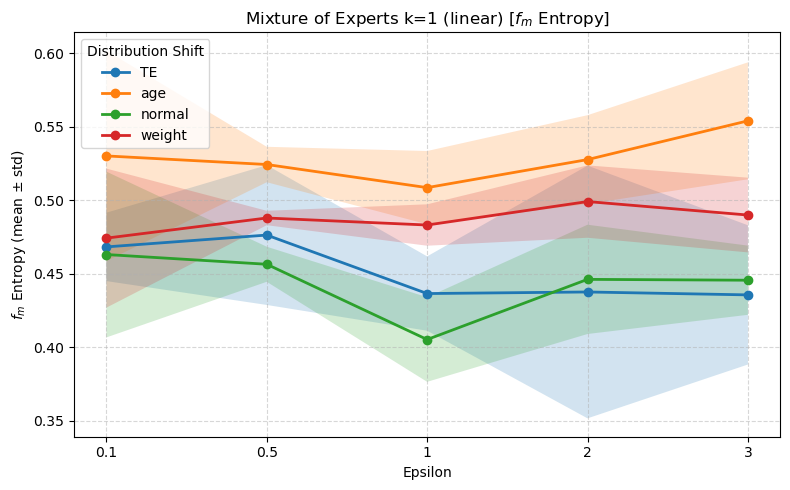

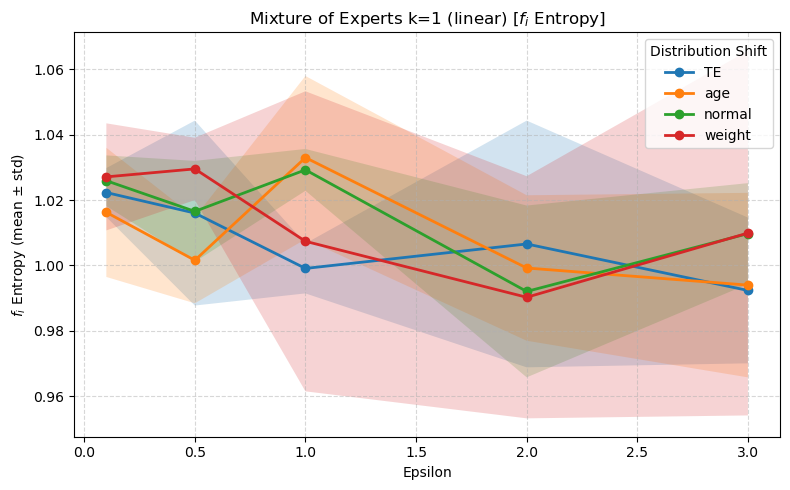

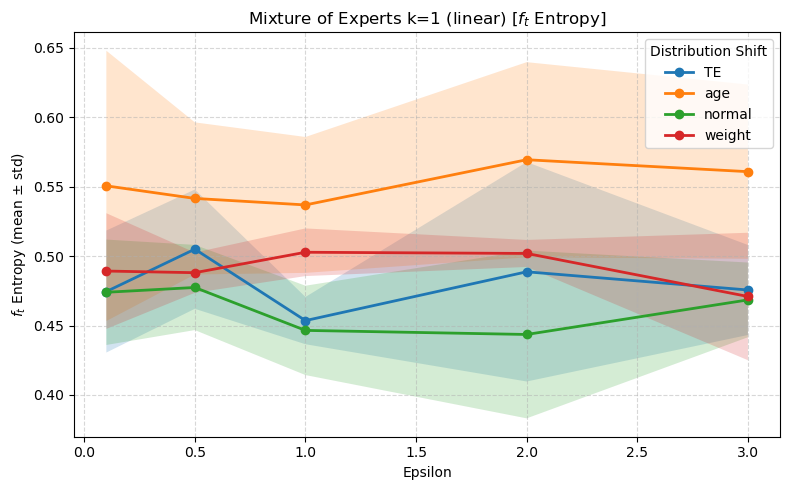

epsilon   Shift multimodal.test.classifier.entropy            \
                                                 mean       std   
0      0.1      TE                           0.468232  0.023253   
1      0.1     age                           0.530135  0.071575   
2      0.1  normal                           0.463045  0.056414   
3      0.1  weight                           0.474197  0.047319   
4      0.5      TE                           0.476285  0.047545   
5      0.5     age                           0.524292  0.012052   
6      0.5  normal                           0.456425  0.011930   
7      0.5  weight                           0.487898  0.004903   
8      1.0      TE                           0.436491  0.025295   
9      1.0     age                           0.508560  0.024910   
10     1.0  normal                           0.405212  0.028783   
11     1.0  weight                           0.483121  0.014083   
12     2.0      TE                           0.437565  0.085972   
13     2.0     age                           0.527638  0.030196   
14     2.0  normal                           0.446147  0.037174   
15     2.0  weight                           0.499078  0.024614   
16     3.0      TE                           0.435588  0.047365   
17     3.0     age                           0.554013  0.039780   
18     3.0  normal                           0.445569  0.023533   
19     3.0  weight                           0.489912  0.025417   

   image.test.classifier.entropy           tabular.test.classifier.entropy  \
                            mean       std                            mean   
0                       1.022282  0.007477                        0.474480   
1                       1.016226  0.019725                        0.550644   
2                       1.025891  0.007739                        0.473958   
3                       1.027069  0.016349                        0.489253   
4                       1.016010  0.028240                        0.505026   
5                       1.001592  0.013142                        0.541586   
6                       1.016533  0.015414                        0.477407   
7                       1.029503  0.009513                        0.488069   
8                       0.999105  0.007628                        0.453547   
9                       1.032949  0.024932                        0.536899   
10                      1.029209  0.006383                        0.446487   
11                      1.007387  0.045823                        0.502796   
12                      1.006574  0.037679                        0.488717   
13                      0.999235  0.022212                        0.569474   
14                      0.992072  0.026234                        0.443548   
15                      0.990293  0.036974                        0.501939   
16                      0.992375  0.022253                        0.475603   
17                      0.994011  0.028180                        0.560873   
18                      1.009736  0.015420                        0.468468   
19                      1.009903  0.055695                        0.470923   

              test.acc           test.balanced_acc            
         std      mean       std              mean       std  
0   0.043956  0.774222  0.127787          0.694545  0.202565  
1   0.097389  0.775111  0.028514          0.705336  0.116453  
2   0.037974  0.707556  0.150291          0.613407  0.134351  
3   0.041672  0.827556  0.051731          0.778374  0.122540  
4   0.042975  0.741333  0.166619          0.656516  0.239138  
5   0.054805  0.791111  0.009365          0.755239  0.048997  
6   0.030691  0.706667  0.145498          0.616780  0.136072  
7   0.014499  0.828444  0.050055          0.781551  0.124159  
8   0.017034  0.832889  0.033766          0.746405  0.104535  
9   0.048967  0.754667  0.057007          0.632662  0.214160  
10  0.032187  0.742222  0.124575          0.628776  0.1

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
8       TE     1.0  0.832889  0.033766          0.746405  0.104535
5      age     0.5  0.791111  0.009365          0.755239  0.048997
10  normal     1.0  0.742222  0.124575          0.628776  0.104472
7   weight     0.5  0.828444  0.050055          0.781551  0.124159

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [57]:
plot_results(path="final_dataset/MoE1-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=2 linear


Shift: TE
MoE.test.weight0 max value: 0.3618147273858388
MoE.test.weight1 max value: 0.3440180122852325
MoE.test.weight2 max value: 0.43936432401339215

Shift: age
MoE.test.weight0 max value: 0.31105600794156385
MoE.test.weight1 max value: 0.4200569788614908
MoE.test.weight2 max value: 0.4211178620656331

Shift: normal
MoE.test.weight0 max value: 0.41251835227012634
MoE.test.weight1 max value: 0.40761415163675946
MoE.test.weight2 max value: 0.33982832233111065

Shift: weight
MoE.test.weight0 max value: 0.38463910420735675
MoE.test.weight1 max value: 0.3164559304714203
MoE.test.weight2 max value: 0.4221359093983968


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
12      TE       2         0.361815  0.068816         0.320349  0.031073   
16      TE       3         0.334605  0.047115         0.344018  0.037930   
0       TE     0.1         0.292993  0.033247         0.267643  0.038337   
5      age     0.5         0.311056  0.051528         0.352454  0.077019   
17     age       3         0.284948  0.068680         0.420057  0.017562   
1      age     0.1         0.256043  0.073876         0.322839  0.045230   
2   normal     0.1         0.412518  0.014119         0.287764  0.058659   
14  normal       2         0.254601  0.050589         0.407614  0.055641   
6   normal     0.5         0.324802  0.079680         0.335370  0.023062   
19  weight       3         0.384639  0.053768         0.278042  0.035392   
15  weight       2         0.321484  0.037470         0.316456  0.024717   
3   weight     0.1         0.336711  0.091423         0.241153  0.018372   

   MoE.test.weight2            
               mean       std  
12         0.317837  0.078118  
16         0.321377  0.041434  
0          0.439364  0.014687  
5          0.336490  0.068140  
17         0.294995  0.052753  
1          0.421118  0.069663  
2          0.299718  0.067670  
14         0.337785  0.071627  
6          0.339828  0.058413  
19         0.337319  0.087410  
15         0.362060  0.062102  
3          0.422136  0.109653

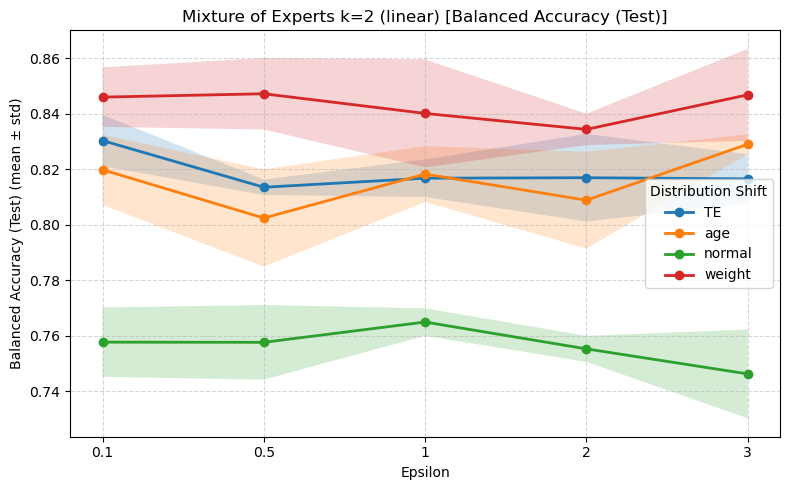

epsilon   Shift test.balanced_acc            test.acc            \
                                mean       std      mean       std   
0      0.1      TE          0.830309  0.009207  0.852444  0.001540   
1      0.1     age          0.819800  0.012624  0.813333  0.018667   
2      0.1  normal          0.757704  0.012496  0.841778  0.008572   
3      0.1  weight          0.845963  0.010713  0.855111  0.003079   
4      0.5      TE          0.813491  0.002786  0.848889  0.004073   
5      0.5     age          0.802409  0.017522  0.803556  0.004073   
6      0.5  normal          0.757639  0.013448  0.826667  0.030052   
7      0.5  weight          0.847166  0.012864  0.856000  0.004619   
8      1.0      TE          0.816755  0.006771  0.845333  0.004619   
9      1.0     age          0.818245  0.010054  0.809778  0.008572   
10     1.0  normal          0.764948  0.004952  0.831111  0.013422   
11     1.0  weight          0.840090  0.019445  0.845333  0.009615   
12     2.0      TE          0.816931  0.015768  0.848000  0.002667   
13     2.0     age          0.808833  0.017441  0.808889  0.010777   
14     2.0  normal          0.755276  0.004692  0.825778  0.010777   
15     2.0  weight          0.834340  0.005644  0.848000  0.000000   
16     3.0      TE          0.816512  0.008852  0.847111  0.006158   
17     3.0     age          0.829005  0.003541  0.802667  0.012220   
18     3.0  normal          0.746266  0.015974  0.825778  0.013422   
19     3.0  weight          0.846787  0.016575  0.848889  0.010777   

   test.balanced_acc            
                mean       std  
0           0.830309  0.009207  
1           0.819800  0.012624  
2           0.757704  0.012496  
3           0.845963  0.010713  
4           0.813491  0.002786  
5           0.802409  0.017522  
6           0.757639  0.013448  
7           0.847166  0.012864  
8           0.816755  0.006771  
9           0.818245  0.010054  
10          0.764948  0.004952  
11          0.840090  0.019445  
12          0.816931  0.015768  
13          0.808833  0.017441  
14          0.755276  0.004692  
15          0.834340  0.005644  
16          0.816512  0.008852  
17          0.829005  0.003541  
18          0.746266  0.015974  
19          0.846787  0.016575

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
0       TE     0.1  0.852444  0.001540          0.830309  0.009207
17     age     3.0  0.802667  0.012220          0.829005  0.003541
10  normal     1.0  0.831111  0.013422          0.764948  0.004952
7   weight     0.5  0.856000  0.004619          0.847166  0.012864

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [58]:
plot_results(path="final_dataset/MoE2-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=2 (linear)")

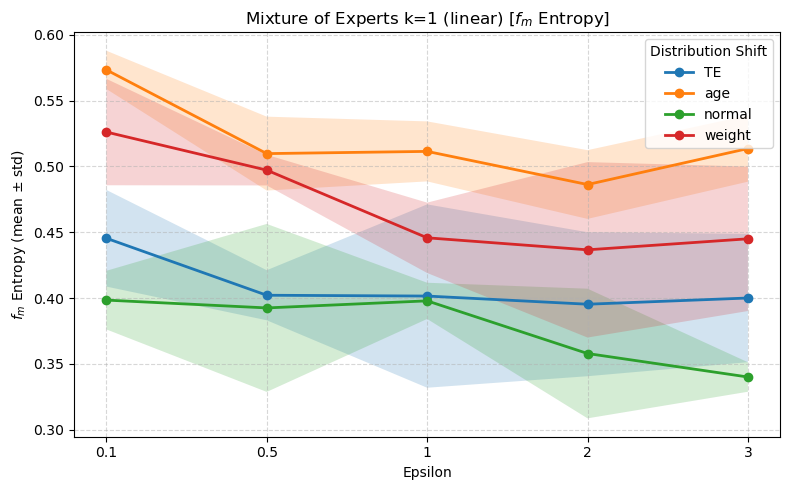

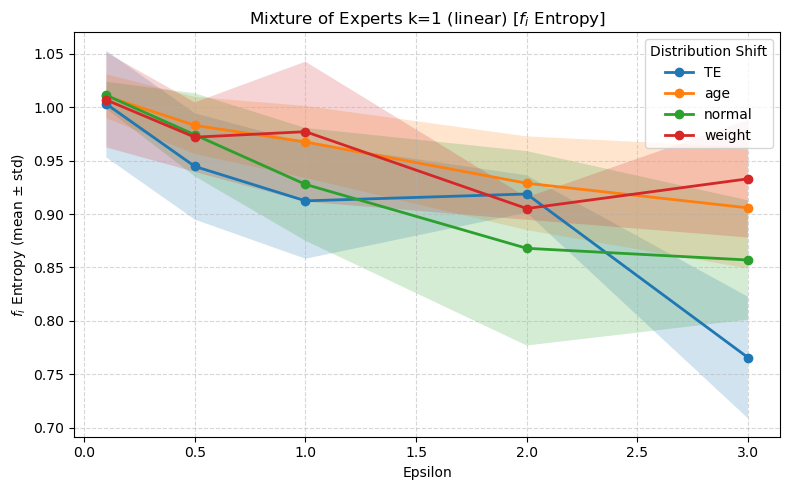

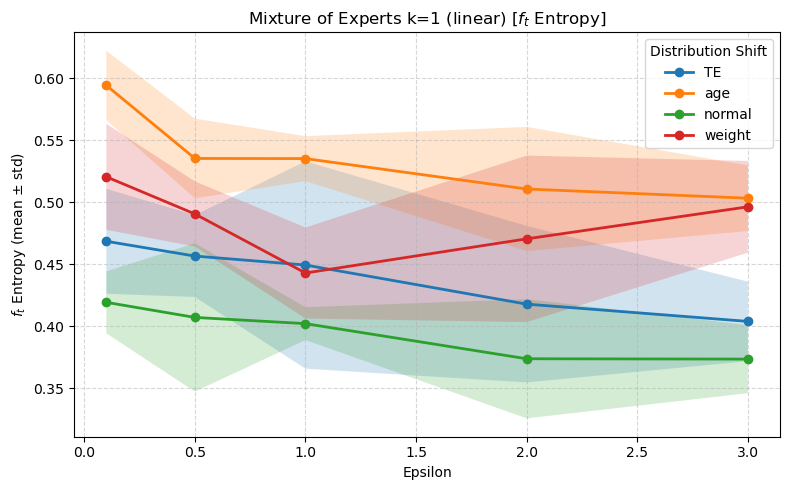

epsilon   Shift multimodal.test.classifier.entropy            \
                                                 mean       std   
0      0.1      TE                           0.445438  0.036698   
1      0.1     age                           0.573369  0.014533   
2      0.1  normal                           0.398456  0.022250   
3      0.1  weight                           0.526121  0.040429   
4      0.5      TE                           0.402146  0.019020   
5      0.5     age                           0.509739  0.028068   
6      0.5  normal                           0.392516  0.063802   
7      0.5  weight                           0.497189  0.011628   
8      1.0      TE                           0.401533  0.069642   
9      1.0     age                           0.511422  0.022792   
10     1.0  normal                           0.397887  0.013762   
11     1.0  weight                           0.445782  0.026712   
12     2.0      TE                           0.395332  0.054699   
13     2.0     age                           0.486246  0.026110   
14     2.0  normal                           0.357877  0.049239   
15     2.0  weight                           0.436648  0.066628   
16     3.0      TE                           0.400048  0.048745   
17     3.0     age                           0.513592  0.025169   
18     3.0  normal                           0.340039  0.011200   
19     3.0  weight                           0.445020  0.054857   

   image.test.classifier.entropy           tabular.test.classifier.entropy  \
                            mean       std                            mean   
0                       1.003036  0.049956                        0.468587   
1                       1.010348  0.020476                        0.594319   
2                       1.011294  0.012586                        0.419320   
3                       1.006860  0.044405                        0.520571   
4                       0.944645  0.049776                        0.456655   
5                       0.983057  0.026733                        0.535403   
6                       0.974241  0.038913                        0.407157   
7                       0.972038  0.032566                        0.490646   
8                       0.912411  0.054210                        0.449429   
9                       0.967557  0.033713                        0.535285   
10                      0.927845  0.052817                        0.402146   
11                      0.977175  0.065559                        0.442980   
12                      0.918844  0.017485                        0.417871   
13                      0.928903  0.043858                        0.510747   
14                      0.867986  0.091031                        0.373802   
15                      0.905222  0.010535                        0.470552   
16                      0.765697  0.056942                        0.403946   
17                      0.905832  0.056705                        0.503332   
18                      0.857022  0.055918                        0.373540   
19                      0.933046  0.054975                        0.496379   

              test.acc           test.balanced_acc            
         std      mean       std              mean       std  
0   0.042302  0.852444  0.001540          0.830309  0.009207  
1   0.027985  0.813333  0.018667          0.819800  0.012624  
2   0.024991  0.841778  0.008572          0.757704  0.012496  
3   0.042757  0.855111  0.003079          0.845963  0.010713  
4   0.033019  0.848889  0.004073          0.813491  0.002786  
5   0.032121  0.803556  0.004073          0.802409  0.017522  
6   0.059818  0.826667  0.030052          0.757639  0.013448  
7   0.026277  0.856000  0.004619          0.847166  0.012864  
8   0.083626  0.845333  0.004619          0.816755  0.006771  
9   0.018105  0.809778  0.008572          0.818245  0.010054  
10  0.013258  0.831111  0.013422          0.764948  0.0

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
0       TE     0.1  0.852444  0.001540          0.830309  0.009207
17     age     3.0  0.802667  0.012220          0.829005  0.003541
10  normal     1.0  0.831111  0.013422          0.764948  0.004952
7   weight     0.5  0.856000  0.004619          0.847166  0.012864

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [59]:
plot_results(path="final_dataset/MoE2-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=2 MLP


Shift: TE
MoE.test.weight0 max value: 0.39267919460932416
MoE.test.weight1 max value: 0.3408753474553426
MoE.test.weight2 max value: 0.34342190623283386

Shift: age
MoE.test.weight0 max value: 0.4073382616043091
MoE.test.weight1 max value: 0.4058916966120402
MoE.test.weight2 max value: 0.30863603452841437

Shift: normal
MoE.test.weight0 max value: 0.3199845055739085
MoE.test.weight1 max value: 0.4008840223153432
MoE.test.weight2 max value: 0.3566424747308095

Shift: weight
MoE.test.weight0 max value: 0.36417939762274426
MoE.test.weight1 max value: 0.3186662296454112
MoE.test.weight2 max value: 0.411188006401062


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.392679  0.099531         0.313094  0.040123   
8       TE       1         0.359405  0.060616         0.340875  0.031347   
12      TE       2         0.330618  0.074373         0.325960  0.069011   
17     age       3         0.407338  0.008679         0.370275  0.107114   
9      age       1         0.290445  0.073191         0.405892  0.017727   
1      age     0.1         0.368457  0.080691         0.322907  0.054673   
6   normal     0.5         0.319985  0.063174         0.374221  0.030721   
18  normal       3         0.262229  0.065240         0.400884  0.018374   
2   normal     0.1         0.293176  0.071717         0.350182  0.043536   
7   weight     0.5         0.364179  0.140770         0.294973  0.059762   
19  weight       3         0.296193  0.066976         0.318666  0.032898   
3   weight     0.1         0.292632  0.128722         0.296180  0.084747   

   MoE.test.weight2            
               mean       std  
0          0.294227  0.067672  
8          0.299720  0.046681  
12         0.343422  0.052774  
17         0.222386  0.099585  
9          0.303664  0.064991  
1          0.308636  0.123846  
6          0.305795  0.093851  
18         0.336887  0.066135  
2          0.356642  0.099722  
7          0.340847  0.083553  
19         0.385140  0.064905  
3          0.411188  0.097266

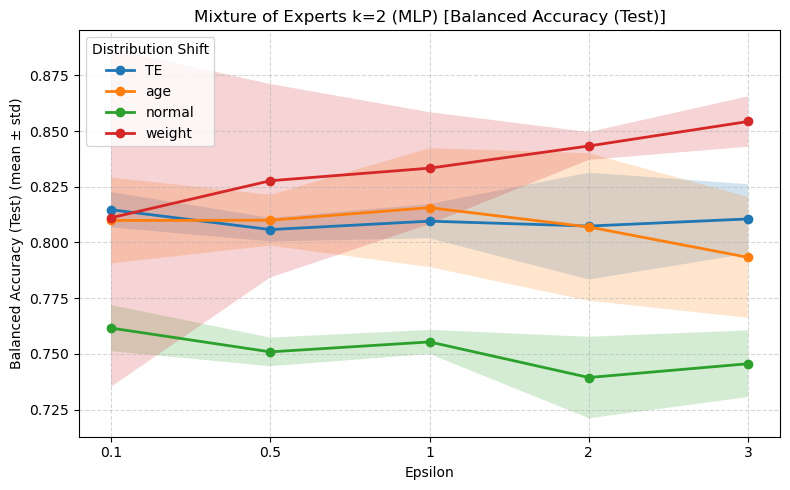

epsilon   Shift test.balanced_acc            test.acc            \
                                mean       std      mean       std   
0      0.1      TE          0.814717  0.007950  0.844444  0.003079   
1      0.1     age          0.809879  0.019287  0.812444  0.012317   
2      0.1  normal          0.761576  0.010344  0.838222  0.004073   
3      0.1  weight          0.811093  0.075883  0.837333  0.020133   
4      0.5      TE          0.805797  0.005299  0.843556  0.005551   
5      0.5     age          0.810012  0.011398  0.817778  0.006158   
6      0.5  normal          0.750878  0.006420  0.833778  0.010777   
7      0.5  weight          0.827729  0.043435  0.840889  0.010777   
8      1.0      TE          0.809582  0.007710  0.848000  0.009615   
9      1.0     age          0.815654  0.026724  0.813333  0.009615   
10     1.0  normal          0.755347  0.005416  0.840000  0.009615   
11     1.0  weight          0.833379  0.025127  0.839111  0.016294   
12     2.0      TE          0.807376  0.023985  0.847111  0.008572   
13     2.0     age          0.806970  0.033124  0.802667  0.032332   
14     2.0  normal          0.739371  0.018297  0.814222  0.026309   
15     2.0  weight          0.843343  0.006243  0.852444  0.006711   
16     3.0      TE          0.810584  0.015585  0.845333  0.005333   
17     3.0     age          0.793319  0.027147  0.815111  0.003079   
18     3.0  normal          0.745561  0.014977  0.829333  0.009615   
19     3.0  weight          0.854335  0.011310  0.852444  0.007698   

   test.balanced_acc            
                mean       std  
0           0.814717  0.007950  
1           0.809879  0.019287  
2           0.761576  0.010344  
3           0.811093  0.075883  
4           0.805797  0.005299  
5           0.810012  0.011398  
6           0.750878  0.006420  
7           0.827729  0.043435  
8           0.809582  0.007710  
9           0.815654  0.026724  
10          0.755347  0.005416  
11          0.833379  0.025127  
12          0.807376  0.023985  
13          0.806970  0.033124  
14          0.739371  0.018297  
15          0.843343  0.006243  
16          0.810584  0.015585  
17          0.793319  0.027147  
18          0.745561  0.014977  
19          0.854335  0.011310

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
0       TE     0.1  0.844444  0.003079          0.814717  0.007950
9      age     1.0  0.813333  0.009615          0.815654  0.026724
2   normal     0.1  0.838222  0.004073          0.761576  0.010344
19  weight     3.0  0.852444  0.007698          0.854335  0.011310

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [60]:
plot_results(path="final_dataset/MoE2-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=2 (MLP)")

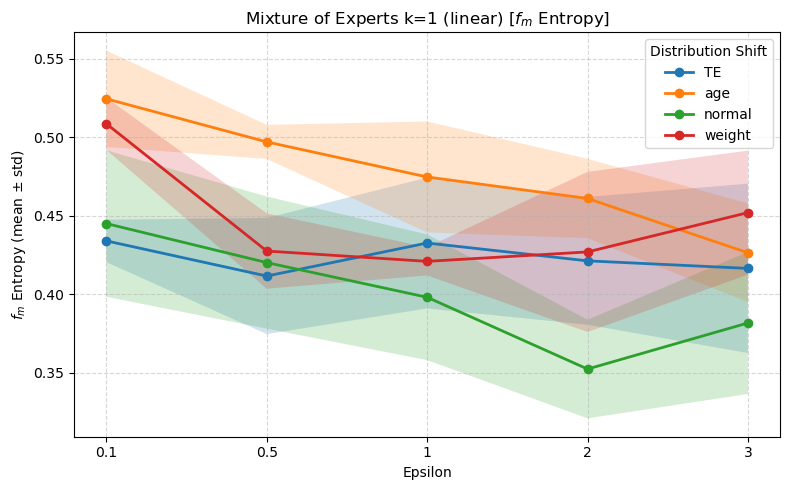

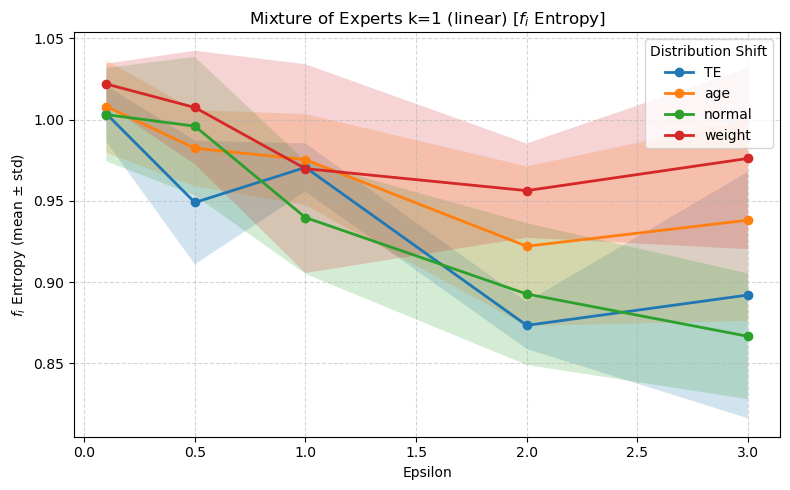

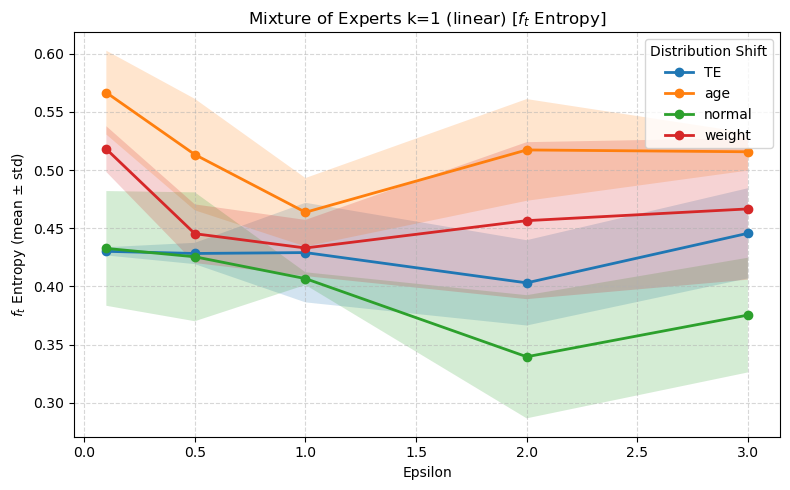

epsilon   Shift multimodal.test.classifier.entropy            \
                                                 mean       std   
0      0.1      TE                           0.434119  0.013542   
1      0.1     age                           0.524614  0.030648   
2      0.1  normal                           0.445155  0.046652   
3      0.1  weight                           0.508732  0.016637   
4      0.5      TE                           0.411722  0.037004   
5      0.5     age                           0.497168  0.010859   
6      0.5  normal                           0.420303  0.042097   
7      0.5  weight                           0.427654  0.024008   
8      1.0      TE                           0.432759  0.041673   
9      1.0     age                           0.474830  0.035351   
10     1.0  normal                           0.398204  0.040038   
11     1.0  weight                           0.421075  0.008994   
12     2.0      TE                           0.421401  0.040689   
13     2.0     age                           0.461127  0.025245   
14     2.0  normal                           0.352480  0.031407   
15     2.0  weight                           0.427082  0.050993   
16     3.0      TE                           0.416592  0.053949   
17     3.0     age                           0.426533  0.031439   
18     3.0  normal                           0.381830  0.045224   
19     3.0  weight                           0.452119  0.039497   

   image.test.classifier.entropy           tabular.test.classifier.entropy  \
                            mean       std                            mean   
0                       1.003639  0.017310                        0.430176   
1                       1.008075  0.028433                        0.566562   
2                       1.003117  0.028782                        0.432682   
3                       1.021965  0.012556                        0.518008   
4                       0.948999  0.038097                        0.428336   
5                       0.982430  0.023421                        0.513319   
6                       0.996006  0.042691                        0.425484   
7                       1.007514  0.034962                        0.445332   
8                       0.970603  0.014813                        0.429107   
9                       0.975415  0.028049                        0.463735   
10                      0.939726  0.034711                        0.406735   
11                      0.969853  0.064299                        0.433049   
12                      0.873328  0.014549                        0.403091   
13                      0.922069  0.049194                        0.517301   
14                      0.892636  0.043679                        0.339582   
15                      0.956310  0.029031                        0.456536   
16                      0.892011  0.075944                        0.445687   
17                      0.938106  0.062028                        0.515731   
18                      0.866585  0.038747                        0.375404   
19                      0.976124  0.055862                        0.466633   

              test.acc           test.balanced_acc            
         std      mean       std              mean       std  
0   0.003540  0.844444  0.003079          0.814717  0.007950  
1   0.036009  0.812444  0.012317          0.809879  0.019287  
2   0.049291  0.838222  0.004073          0.761576  0.010344  
3   0.019668  0.837333  0.020133          0.811093  0.075883  
4   0.009158  0.843556  0.005551          0.805797  0.005299  
5   0.047886  0.817778  0.006158          0.810012  0.011398  
6   0.055368  0.833778  0.010777          0.750878  0.006420  
7   0.025194  0.840889  0.010777          0.827729  0.043435  
8   0.042782  0.848000  0.009615          0.809582  0.007710  
9   0.029409  0.813333  0.009615          0.815654  0.026724  
10  0.005455  0.840000  0.009615          0.755347  0.0

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
0       TE     0.1  0.844444  0.003079          0.814717  0.007950
9      age     1.0  0.813333  0.009615          0.815654  0.026724
2   normal     0.1  0.838222  0.004073          0.761576  0.010344
19  weight     3.0  0.852444  0.007698          0.854335  0.011310

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [61]:
plot_results(path="final_dataset/MoE2-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=3 Linear


Shift: TE
MoE.test.weight0 max value: 0.37946372230847675
MoE.test.weight1 max value: 0.3237983783086141
MoE.test.weight2 max value: 0.3510879576206207

Shift: age
MoE.test.weight0 max value: 0.3576858739058177
MoE.test.weight1 max value: 0.396039754152298
MoE.test.weight2 max value: 0.34822901089986164

Shift: normal
MoE.test.weight0 max value: 0.35995422800381977
MoE.test.weight1 max value: 0.3351566791534423
MoE.test.weight2 max value: 0.3570223550001779

Shift: weight
MoE.test.weight0 max value: 0.40086983640988666
MoE.test.weight1 max value: 0.31201627850532526
MoE.test.weight2 max value: 0.38619881868362427


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.379464  0.035965         0.274676  0.018437   
16      TE       3         0.349724  0.003430         0.323798  0.032796   
8       TE       1         0.349311  0.034317         0.299601  0.041790   
9      age       1         0.357686  0.046329         0.369919  0.038748   
13     age       2         0.346797  0.046579         0.396040  0.024992   
1      age     0.1         0.323641  0.022237         0.328130  0.051082   
6   normal     0.5         0.359954  0.034379         0.321594  0.038081   
10  normal       1         0.315991  0.018214         0.335157  0.019128   
14  normal       2         0.347038  0.053092         0.295939  0.047891   
15  weight       2         0.400870  0.038467         0.272450  0.053579   
19  weight       3         0.345870  0.037468         0.312016  0.039149   
3   weight     0.1         0.349962  0.027422         0.263840  0.016519   

   MoE.test.weight2            
               mean       std  
0          0.345861  0.030583  
16         0.326477  0.031327  
8          0.351088  0.029848  
9          0.272395  0.071227  
13         0.257164  0.033169  
1          0.348229  0.030598  
6          0.318452  0.007088  
10         0.348853  0.036590  
14         0.357022  0.027460  
15         0.326680  0.070185  
19         0.342114  0.023683  
3          0.386199  0.022082

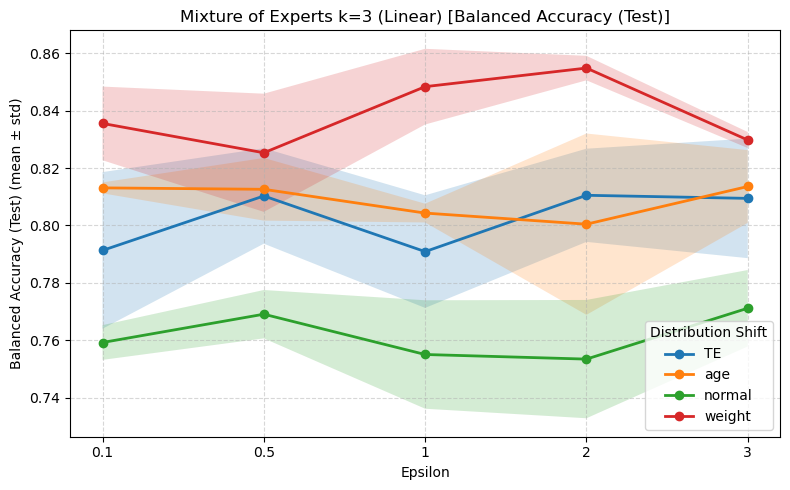

epsilon   Shift test.balanced_acc            test.acc            \
                                mean       std      mean       std   
0      0.1      TE          0.791303  0.027286  0.848889  0.008147   
1      0.1     age          0.813093  0.001900  0.813333  0.010667   
2      0.1  normal          0.759218  0.006047  0.842667  0.002667   
3      0.1  weight          0.835548  0.012834  0.850667  0.000000   
4      0.5      TE          0.810276  0.016624  0.848889  0.004073   
5      0.5     age          0.812595  0.010916  0.808000  0.014111   
6      0.5  normal          0.769080  0.008427  0.835556  0.023901   
7      0.5  weight          0.825321  0.020587  0.851556  0.004073   
8      1.0      TE          0.790885  0.019617  0.848000  0.010667   
9      1.0     age          0.804314  0.003269  0.800000  0.000000   
10     1.0  normal          0.755039  0.018891  0.839111  0.011102   
11     1.0  weight          0.848360  0.013185  0.852444  0.005551   
12     2.0      TE          0.810509  0.016233  0.851556  0.003079   
13     2.0     age          0.800441  0.031589  0.813333  0.009615   
14     2.0  normal          0.753434  0.020606  0.823111  0.019291   
15     2.0  weight          0.854834  0.004266  0.845333  0.016221   
16     3.0      TE          0.809435  0.020826  0.853333  0.007055   
17     3.0     age          0.813573  0.012682  0.809778  0.010096   
18     3.0  normal          0.771162  0.013305  0.845333  0.007055   
19     3.0  weight          0.829765  0.002788  0.840000  0.009238   

   test.balanced_acc            
                mean       std  
0           0.791303  0.027286  
1           0.813093  0.001900  
2           0.759218  0.006047  
3           0.835548  0.012834  
4           0.810276  0.016624  
5           0.812595  0.010916  
6           0.769080  0.008427  
7           0.825321  0.020587  
8           0.790885  0.019617  
9           0.804314  0.003269  
10          0.755039  0.018891  
11          0.848360  0.013185  
12          0.810509  0.016233  
13          0.800441  0.031589  
14          0.753434  0.020606  
15          0.854834  0.004266  
16          0.809435  0.020826  
17          0.813573  0.012682  
18          0.771162  0.013305  
19          0.829765  0.002788

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
12      TE     2.0  0.851556  0.003079          0.810509  0.016233
17     age     3.0  0.809778  0.010096          0.813573  0.012682
18  normal     3.0  0.845333  0.007055          0.771162  0.013305
15  weight     2.0  0.845333  0.016221          0.854834  0.004266

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [62]:
plot_results(path="final_dataset/MoE3-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=3 (Linear)")

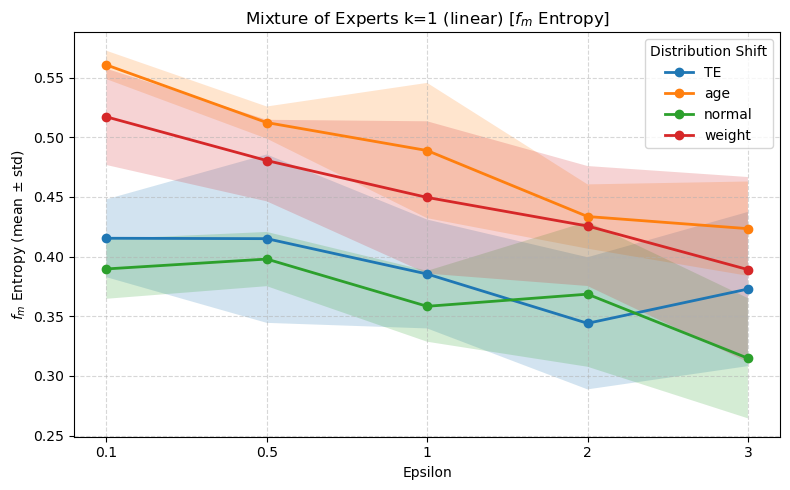

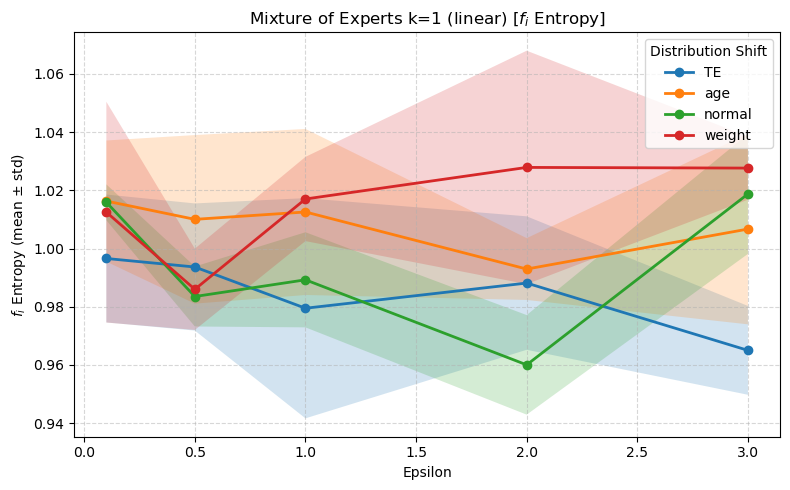

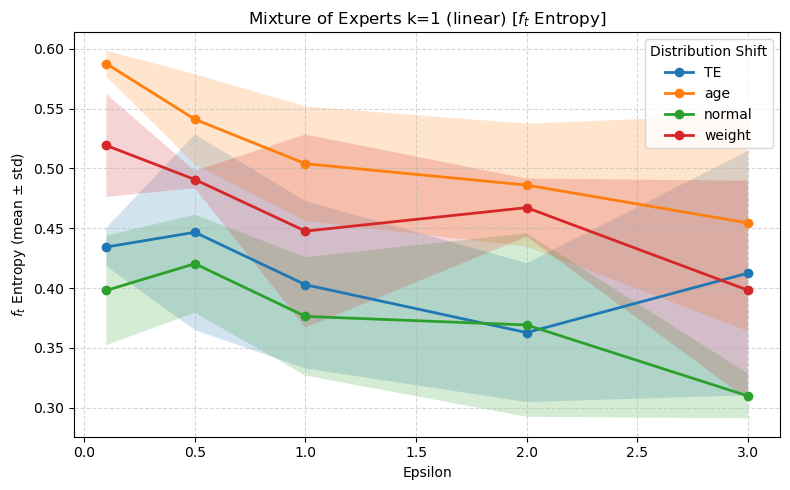

epsilon   Shift multimodal.test.classifier.entropy            \
                                                 mean       std   
0      0.1      TE                           0.415387  0.032612   
1      0.1     age                           0.560620  0.011895   
2      0.1  normal                           0.389679  0.025009   
3      0.1  weight                           0.517123  0.040351   
4      0.5      TE                           0.415044  0.070554   
5      0.5     age                           0.512310  0.013462   
6      0.5  normal                           0.397950  0.022723   
7      0.5  weight                           0.480482  0.034160   
8      1.0      TE                           0.385434  0.045613   
9      1.0     age                           0.488877  0.056667   
10     1.0  normal                           0.358365  0.029687   
11     1.0  weight                           0.449588  0.063785   
12     2.0      TE                           0.344120  0.055354   
13     2.0     age                           0.433588  0.026924   
14     2.0  normal                           0.368542  0.060826   
15     2.0  weight                           0.425639  0.050250   
16     3.0      TE                           0.372840  0.064600   
17     3.0     age                           0.423421  0.039514   
18     3.0  normal                           0.314854  0.050359   
19     3.0  weight                           0.389128  0.077545   

   image.test.classifier.entropy           tabular.test.classifier.entropy  \
                            mean       std                            mean   
0                       0.996577  0.021960                        0.434290   
1                       1.016298  0.020800                        0.587648   
2                       1.015872  0.006157                        0.398014   
3                       1.012486  0.037914                        0.519228   
4                       0.993650  0.021829                        0.446616   
5                       1.010016  0.028946                        0.541103   
6                       0.983516  0.010298                        0.420324   
7                       0.985988  0.013956                        0.490753   
8                       0.979491  0.037810                        0.402736   
9                       1.012549  0.028512                        0.503977   
10                      0.989254  0.016327                        0.376248   
11                      1.017006  0.014455                        0.447593   
12                      0.988138  0.022916                        0.362703   
13                      0.992951  0.010609                        0.486102   
14                      0.960048  0.017097                        0.369083   
15                      1.027851  0.040074                        0.467245   
16                      0.965028  0.015251                        0.412447   
17                      1.006680  0.032718                        0.454426   
18                      1.018728  0.020578                        0.309688   
19                      1.027620  0.010843                        0.398170   

              test.acc           test.balanced_acc            
         std      mean       std              mean       std  
0   0.016096  0.848889  0.008147          0.791303  0.027286  
1   0.010843  0.813333  0.010667          0.813093  0.001900  
2   0.045754  0.842667  0.002667          0.759218  0.006047  
3   0.043018  0.850667  0.000000          0.835548  0.012834  
4   0.081795  0.848889  0.004073          0.810276  0.016624  
5   0.037801  0.808000  0.014111          0.812595  0.010916  
6   0.041059  0.835556  0.023901          0.769080  0.008427  
7   0.007250  0.851556  0.004073          0.825321  0.020587  
8   0.070026  0.848000  0.010667          0.790885  0.019617  
9   0.047843  0.800000  0.000000          0.804314  0.003269  
10  0.049479  0.839111  0.011102          0.755039  0.0

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
12      TE     2.0  0.851556  0.003079          0.810509  0.016233
17     age     3.0  0.809778  0.010096          0.813573  0.012682
18  normal     3.0  0.845333  0.007055          0.771162  0.013305
15  weight     2.0  0.845333  0.016221          0.854834  0.004266

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [63]:
plot_results(path="final_dataset/MoE3-linear", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## MoE k=3 MLP


Shift: TE
MoE.test.weight0 max value: 0.35298964381217957
MoE.test.weight1 max value: 0.3276186386744181
MoE.test.weight2 max value: 0.3811416029930115

Shift: age
MoE.test.weight0 max value: 0.3613846004009246
MoE.test.weight1 max value: 0.3549264073371887
MoE.test.weight2 max value: 0.33482809861501056

Shift: normal
MoE.test.weight0 max value: 0.3432638148466746
MoE.test.weight1 max value: 0.33418452739715576
MoE.test.weight2 max value: 0.34876482685407

Shift: weight
MoE.test.weight0 max value: 0.3489306370417277
MoE.test.weight1 max value: 0.3095704913139343
MoE.test.weight2 max value: 0.3793160716692607


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
16      TE       3         0.352990  0.013256         0.285852  0.015442   
12      TE       2         0.314958  0.002287         0.327619  0.025705   
4       TE     0.5         0.320128  0.031100         0.298731  0.023095   
5      age     0.5         0.361385  0.025868         0.331151  0.060494   
17     age       3         0.354469  0.014593         0.354926  0.064962   
1      age     0.1         0.360162  0.023748         0.305010  0.028300   
18  normal       3         0.343264  0.026020         0.326351  0.006096   
6   normal     0.5         0.330891  0.002010         0.334185  0.019141   
2   normal     0.1         0.328806  0.004765         0.322429  0.007045   
3   weight     0.1         0.348931  0.027161         0.294692  0.023127   
11  weight       1         0.311113  0.002339         0.309570  0.024066   
11  weight       1         0.311113  0.002339         0.309570  0.024066   

   MoE.test.weight2            
               mean       std  
16         0.361159  0.024785  
12         0.357424  0.027847  
4          0.381142  0.008650  
5          0.307465  0.078894  
17         0.290604  0.063083  
1          0.334828  0.042781  
18         0.330386  0.031981  
6          0.334925  0.017131  
2          0.348765  0.002716  
3          0.356378  0.004039  
11         0.379316  0.022455  
11         0.379316  0.022455

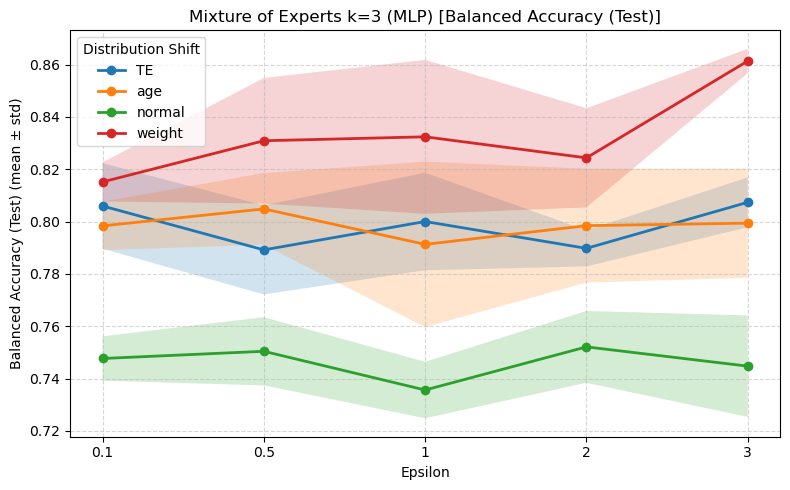

epsilon   Shift test.balanced_acc            test.acc            \
                                mean       std      mean       std   
0      0.1      TE          0.805971  0.016335  0.853333  0.008000   
1      0.1     age          0.798358  0.009264  0.811556  0.004073   
2      0.1  normal          0.747680  0.008474  0.837333  0.002667   
3      0.1  weight          0.815167  0.007457  0.846222  0.010777   
4      0.5      TE          0.789186  0.017029  0.836444  0.008572   
5      0.5     age          0.804848  0.013708  0.808000  0.009615   
6      0.5  normal          0.750434  0.013029  0.837333  0.005333   
7      0.5  weight          0.830897  0.024001  0.851556  0.006711   
8      1.0      TE          0.800033  0.018637  0.845333  0.004619   
9      1.0     age          0.791297  0.031618  0.802667  0.014111   
10     1.0  normal          0.735634  0.010791  0.826667  0.009238   
11     1.0  weight          0.832404  0.029409  0.856000  0.008000   
12     2.0      TE          0.789775  0.006900  0.848000  0.014847   
13     2.0     age          0.798450  0.021751  0.805333  0.007055   
14     2.0  normal          0.752116  0.013727  0.831111  0.015625   
15     2.0  weight          0.824363  0.018944  0.848889  0.012317   
16     3.0      TE          0.807366  0.009519  0.847111  0.008572   
17     3.0     age          0.799407  0.020872  0.803556  0.008572   
18     3.0  normal          0.744755  0.019395  0.824000  0.014111   
19     3.0  weight          0.861370  0.004666  0.852444  0.010096   

   test.balanced_acc            
                mean       std  
0           0.805971  0.016335  
1           0.798358  0.009264  
2           0.747680  0.008474  
3           0.815167  0.007457  
4           0.789186  0.017029  
5           0.804848  0.013708  
6           0.750434  0.013029  
7           0.830897  0.024001  
8           0.800033  0.018637  
9           0.791297  0.031618  
10          0.735634  0.010791  
11          0.832404  0.029409  
12          0.789775  0.006900  
13          0.798450  0.021751  
14          0.752116  0.013727  
15          0.824363  0.018944  
16          0.807366  0.009519  
17          0.799407  0.020872  
18          0.744755  0.019395  
19          0.861370  0.004666

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
16      TE     3.0  0.847111  0.008572          0.807366  0.009519
5      age     0.5  0.808000  0.009615          0.804848  0.013708
14  normal     2.0  0.831111  0.015625          0.752116  0.013727
19  weight     3.0  0.852444  0.010096          0.861370  0.004666

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [64]:
plot_results(path="final_dataset/MoE3-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=3 (MLP)")

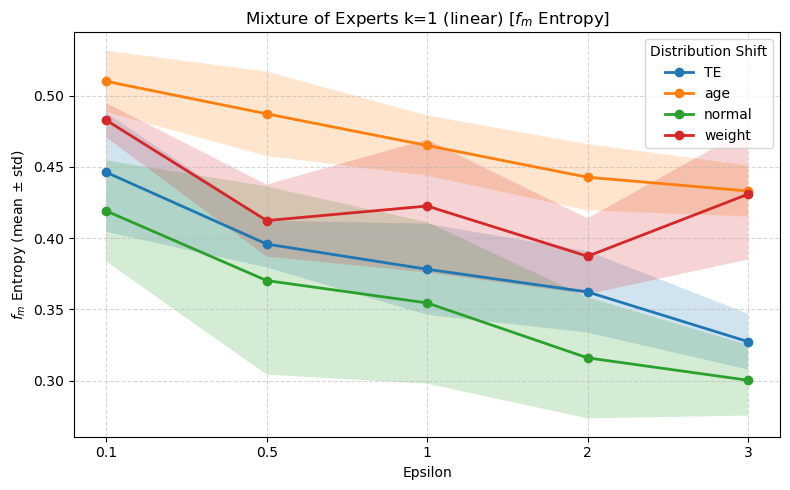

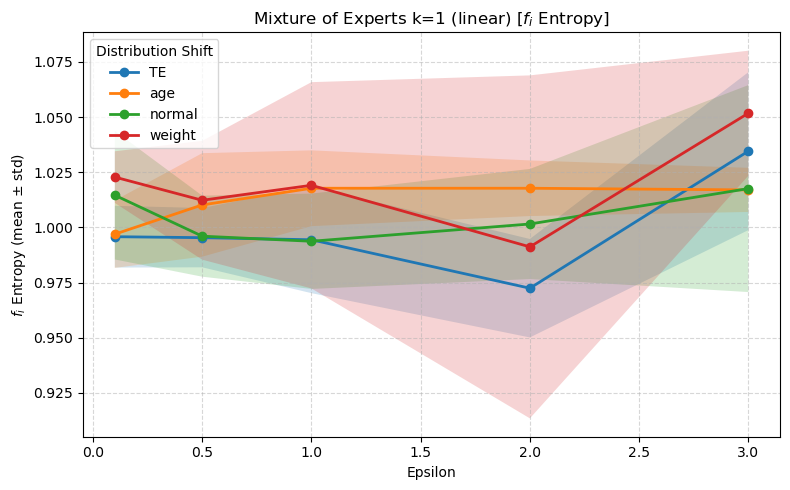

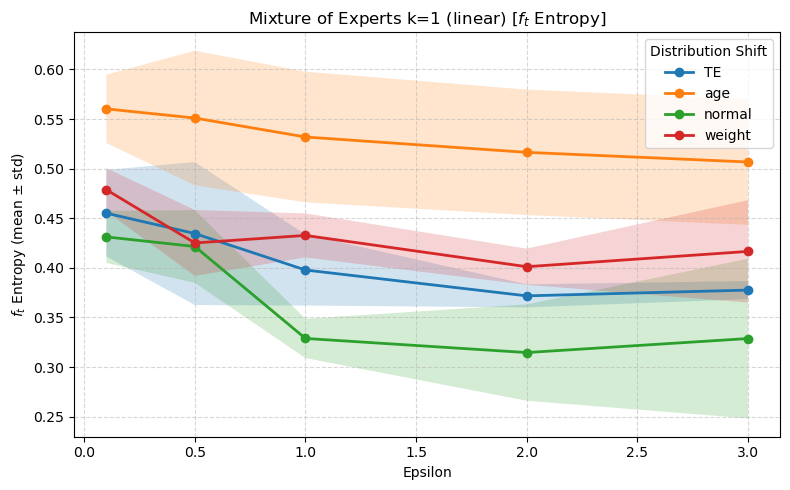

epsilon   Shift multimodal.test.classifier.entropy            \
                                                 mean       std   
0      0.1      TE                           0.446182  0.041792   
1      0.1     age                           0.510083  0.021521   
2      0.1  normal                           0.419039  0.035538   
3      0.1  weight                           0.482727  0.012036   
4      0.5      TE                           0.395831  0.016453   
5      0.5     age                           0.487285  0.029629   
6      0.5  normal                           0.370193  0.066055   
7      0.5  weight                           0.412311  0.025284   
8      1.0      TE                           0.378150  0.031995   
9      1.0     age                           0.465051  0.021120   
10     1.0  normal                           0.354504  0.056705   
11     1.0  weight                           0.422550  0.046703   
12     2.0      TE                           0.362228  0.028559   
13     2.0     age                           0.442769  0.023289   
14     2.0  normal                           0.315930  0.042474   
15     2.0  weight                           0.387267  0.026651   
16     3.0      TE                           0.327346  0.019629   
17     3.0     age                           0.433101  0.017876   
18     3.0  normal                           0.300221  0.024863   
19     3.0  weight                           0.430821  0.045859   

   image.test.classifier.entropy           tabular.test.classifier.entropy  \
                            mean       std                            mean   
0                       0.995793  0.013997                        0.455082   
1                       0.996937  0.015288                        0.560234   
2                       1.014595  0.029116                        0.431173   
3                       1.022813  0.011704                        0.478695   
4                       0.995352  0.013443                        0.434557   
5                       1.010195  0.023457                        0.550984   
6                       0.996028  0.018366                        0.421485   
7                       1.012301  0.026917                        0.425070   
8                       0.994406  0.024197                        0.397798   
9                       1.017756  0.017178                        0.531892   
10                      0.993722  0.021609                        0.328820   
11                      1.019093  0.046748                        0.432670   
12                      0.972442  0.022321                        0.371744   
13                      1.017755  0.012602                        0.516414   
14                      1.001549  0.024953                        0.314595   
15                      0.991185  0.077727                        0.401129   
16                      1.034558  0.035788                        0.377555   
17                      1.017002  0.010006                        0.506695   
18                      1.017602  0.046898                        0.328709   
19                      1.051756  0.028339                        0.416538   

              test.acc           test.balanced_acc            
         std      mean       std              mean       std  
0   0.043638  0.853333  0.008000          0.805971  0.016335  
1   0.034427  0.811556  0.004073          0.798358  0.009264  
2   0.026203  0.837333  0.002667          0.747680  0.008474  
3   0.021832  0.846222  0.010777          0.815167  0.007457  
4   0.072060  0.836444  0.008572          0.789186  0.017029  
5   0.067871  0.808000  0.009615          0.804848  0.013708  
6   0.036626  0.837333  0.005333          0.750434  0.013029  
7   0.033231  0.851556  0.006711          0.830897  0.024001  
8   0.035816  0.845333  0.004619          0.800033  0.018637  
9   0.065845  0.802667  0.014111          0.791297  0.031618  
10  0.019792  0.826667  0.009238          0.735634  0.0

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
16      TE     3.0  0.847111  0.008572          0.807366  0.009519
5      age     0.5  0.808000  0.009615          0.804848  0.013708
14  normal     2.0  0.831111  0.015625          0.752116  0.013727
19  weight     3.0  0.852444  0.010096          0.861370  0.004666

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [65]:
plot_results(path="final_dataset/MoE3-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

### Switch Transformer


Shift: TE
MoE.test.weight0 max value: 0.3333333432674408
MoE.test.weight1 max value: 0.3333333432674408
MoE.test.weight2 max value: 0.3333333432674408

Shift: age
MoE.test.weight0 max value: 0.3333333432674408
MoE.test.weight1 max value: 0.3333333432674408
MoE.test.weight2 max value: 0.3333333432674408

Shift: normal
MoE.test.weight0 max value: 0.3333333432674408
MoE.test.weight1 max value: 0.3333333432674408
MoE.test.weight2 max value: 0.3333333432674408

Shift: weight
MoE.test.weight0 max value: 0.3333333432674408
MoE.test.weight1 max value: 0.3333333432674408
MoE.test.weight2 max value: 0.3333333432674408


Shift epsilon MoE.test.weight0      MoE.test.weight1       \
                               mean  std             mean  std   
0       TE   0.001         0.333333  0.0         0.333333  0.0   
4       TE    0.01         0.333333  0.0         0.333333  0.0   
8       TE     0.1         0.333333  0.0         0.333333  0.0   
12      TE       2         0.333333  0.0         0.333333  0.0   
0       TE   0.001         0.333333  0.0         0.333333  0.0   
4       TE    0.01         0.333333  0.0         0.333333  0.0   
8       TE     0.1         0.333333  0.0         0.333333  0.0   
12      TE       2         0.333333  0.0         0.333333  0.0   
0       TE   0.001         0.333333  0.0         0.333333  0.0   
4       TE    0.01         0.333333  0.0         0.333333  0.0   
8       TE     0.1         0.333333  0.0         0.333333  0.0   
12      TE       2         0.333333  0.0         0.333333  0.0   
1      age   0.001         0.333333  0.0         0.333333  0.0   
5      age    0.01         0.333333  0.0         0.333333  0.0   
9      age     0.1         0.333333  0.0         0.333333  0.0   
13     age       2         0.333333  0.0         0.333333  0.0   
1      age   0.001         0.333333  0.0         0.333333  0.0   
5      age    0.01         0.333333  0.0         0.333333  0.0   
9      age     0.1         0.333333  0.0         0.333333  0.0   
13     age       2         0.333333  0.0         0.333333  0.0   
1      age   0.001         0.333333  0.0         0.333333  0.0   
5      age    0.01         0.333333  0.0         0.333333  0.0   
9      age     0.1         0.333333  0.0         0.333333  0.0   
13     age       2         0.333333  0.0         0.333333  0.0   
2   normal   0.001         0.333333  0.0         0.333333  0.0   
6   normal    0.01         0.333333  0.0         0.333333  0.0   
10  normal     0.1         0.333333  0.0         0.333333  0.0   
14  normal       2         0.333333  0.0         0.333333  0.0   
2   normal   0.001         0.333333  0.0         0.333333  0.0   
6   normal    0.01         0.333333  0.0         0.333333  0.0   
10  normal     0.1         0.333333  0.0         0.333333  0.0   
14  normal       2         0.333333  0.0         0.333333  0.0   
2   normal   0.001         0.333333  0.0         0.333333  0.0   
6   normal    0.01         0.333333  0.0         0.333333  0.0   
10  normal     0.1         0.333333  0.0         0.333333  0.0   
14  normal       2         0.333333  0.0         0.333333  0.0   
3   weight   0.001         0.333333  0.0         0.333333  0.0   
7   weight    0.01         0.333333  0.0         0.333333  0.0   
11  weight     0.1         0.333333  0.0         0.333333  0.0   
15  weight       2         0.333333  0.0         0.333333  0.0   
3   weight   0.001         0.333333  0.0         0.333333  0.0   
7   weight    0.01         0.333333  0.0         0.333333  0.0   
11  weight     0.1         0.333333  0.0         0.333333  0.0   
15  weight       2         0.333333  0.0         0.333333  0.0   
3   weight   0.001         0.333333  0.0         0.333333  0.0   
7   weight    0.01         0.333333  0.0         0.333333  0.0   
11  weight     0.1         0.333333  0.0         0.333333  0.0   
15  weight       2         0.333333  0.0         0.333333  0.0   

   MoE.test.weight2       
               mean  std  
0          0.333333  0.0  
4          0.333333  0.0  
8          0.333333  0.0  
12         0.333333  0.0  
0          0.333333  0.0  
4          0.333333  0.0  
8          0.333333  0.0  
12         0.333333  0.0  
0          0.333333  0.0  
4          0.333333  0.0  
8          0.333333  0.0  
12         0.333333  0.0  
1          0.333333  0.0  
5          0.333333  0.0  
9          0.333333  0.0  
13         0.333333  0.0  
1          0.333333  0.0  
5          0.333333  0.0  
9          0.333333  0.0  
13         0.333333  0.0  
1          0.333333  0.0  
5          0.333333  0.0  
9          0.333333  0.0  
13         0.333333  0.0  
2 

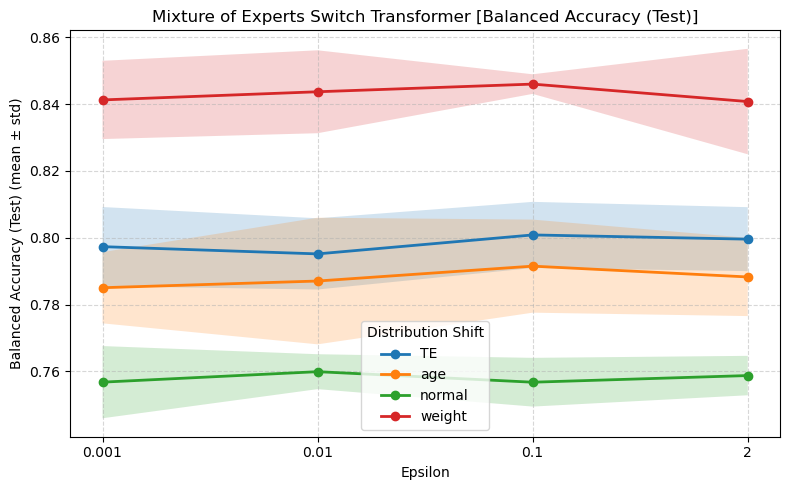

epsilon   Shift  test.acc           test.balanced_acc          
                        mean       std              mean       std
0    0.001      TE  0.850933  0.003654          0.797352  0.011853
1    0.001     age  0.791467  0.011088          0.785066  0.010658
2    0.001  normal  0.846933  0.008907          0.756813  0.010799
3    0.001  weight  0.857067  0.003373          0.841248  0.011707
4    0.010      TE  0.850667  0.004355          0.795185  0.010651
5    0.010     age  0.795467  0.014554          0.787067  0.018942
6    0.010  normal  0.849867  0.006165          0.759947  0.005222
7    0.010  weight  0.859733  0.006434          0.843690  0.012404
8    0.100      TE  0.851200  0.005451          0.800857  0.009892
9    0.100     age  0.799200  0.007442          0.791522  0.013922
10   0.100  normal  0.843733  0.012005          0.756795  0.007290
11   0.100  weight  0.860000  0.003823          0.845985  0.002933
12   2.000      TE  0.851733  0.004207          0.799596  0.009565
13   2.000     age  0.796800  0.008127          0.788284  0.011705
14   2.000  normal  0.848267  0.005822          0.758786  0.005896
15   2.000  weight  0.859200  0.006628          0.840763  0.015778

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
8       TE    0.10  0.851200  0.005451          0.800857  0.009892
9      age    0.10  0.799200  0.007442          0.791522  0.013922
6   normal    0.01  0.849867  0.006165          0.759947  0.005222
11  weight    0.10  0.860000  0.003823          0.845985  0.002933

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [66]:
plot_results(path="final_dataset/MoE1-Switch-NumE3", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts Switch Transformer")

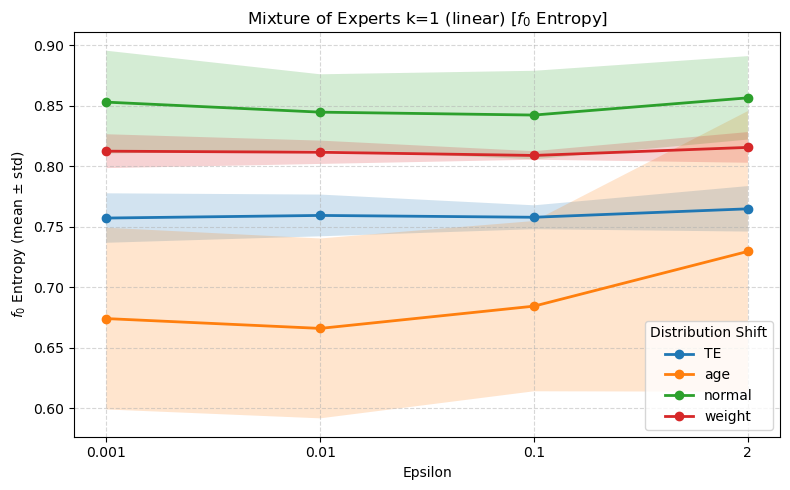

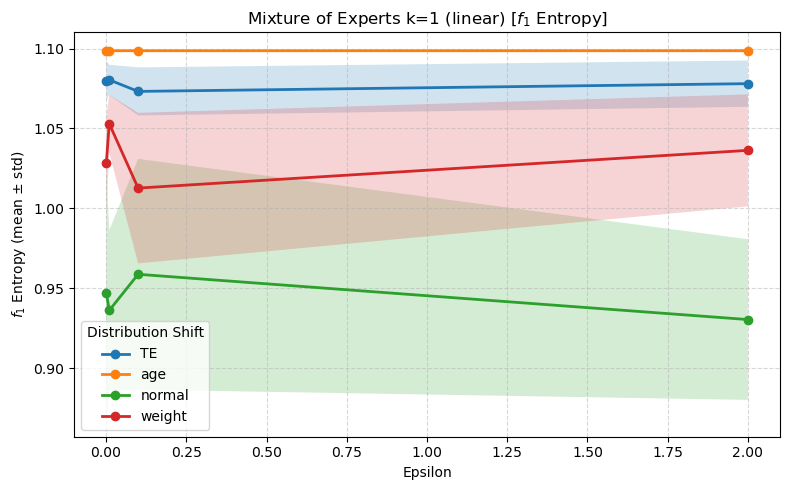

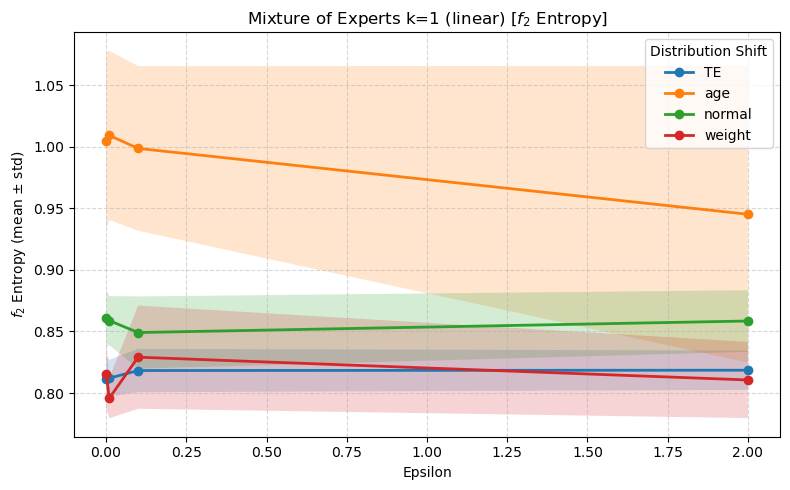

epsilon   Shift test.expert_no0.entropy           test.expert_no1.entropy  \
                                      mean       std                    mean   
0    0.001      TE                0.757259  0.020460                1.079801   
1    0.001     age                0.674103  0.075171                1.098607   
2    0.001  normal                0.853147  0.042525                0.947084   
3    0.001  weight                0.812574  0.014013                1.028493   
4    0.010      TE                0.759422  0.017258                1.080392   
5    0.010     age                0.665971  0.074393                1.098606   
6    0.010  normal                0.844852  0.031316                0.936098   
7    0.010  weight                0.811670  0.009649                1.052967   
8    0.100      TE                0.757909  0.009875                1.073162   
9    0.100     age                0.684388  0.070421                1.098612   
10   0.100  normal                0.842453  0.036617                0.958700   
11   0.100  weight                0.809039  0.003533                1.012643   
12   2.000      TE                0.764889  0.018815                1.078012   
13   2.000     age                0.729689  0.116091                1.098608   
14   2.000  normal                0.856687  0.034510                0.930364   
15   2.000  weight                0.815700  0.012685                1.036266   

             test.expert_no2.entropy            test.acc            \
         std                    mean       std      mean       std   
0   0.012470                0.811379  0.018791  0.850933  0.003654   
1   0.000018                1.004193  0.071974  0.791467  0.011088   
2   0.078545                0.860727  0.022688  0.846933  0.008907   
3   0.028802                0.815105  0.027155  0.857067  0.003373   
4   0.009444                0.812094  0.014933  0.850667  0.004355   
5   0.000020                1.009182  0.068697  0.795467  0.014554   
6   0.050162                0.858821  0.019907  0.849867  0.006165   
7   0.018118                0.795804  0.016325  0.859733  0.006434   
8   0.015040                0.818286  0.017585  0.851200  0.005451   
9   0.000000                0.998576  0.066822  0.799200  0.007442   
10  0.072217                0.849122  0.029321  0.843733  0.012005   
11  0.047107                0.829121  0.041875  0.860000  0.003823   
12  0.014482                0.818551  0.015981  0.851733  0.004207   
13  0.000010                0.945123  0.120411  0.796800  0.008127   
14  0.050266                0.858494  0.025007  0.848267  0.005822   
15  0.035036                0.810628  0.030920  0.859200  0.006628   

   test.balanced_acc            
                mean       std  
0           0.797352  0.011853  
1           0.785066  0.010658  
2           0.756813  0.010799  
3           0.841248  0.011707  
4           0.795185  0.010651  
5           0.787067  0.018942  
6           0.759947  0.005222  
7           0.843690  0.012404  
8           0.800857  0.009892  
9           0.791522  0.013922  
10          0.756795  0.007290  
11          0.845985  0.002933  
12          0.799596  0.009565  
13          0.788284  0.011705  
14          0.758786  0.005896  
15          0.840763  0.015778

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
8       TE    0.10  0.851200  0.005451          0.800857  0.009892
9      age    0.10  0.799200  0.007442          0.791522  0.013922
6   normal    0.01  0.849867  0.006165          0.759947  0.005222
11  weight    0.10  0.860000  0.003823          0.845985  0.002933

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.852444  0.009365          0.819313  0.012563
age     0.818667  0.016000          0.818361  0.009531
normal  0.840000  0.002667          0.752783  0.004264
weight  0.854222  0.007698          0.841267  0.022204

In [67]:
plot_results(path="final_dataset/MoE1-Switch-NumE3", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["test.expert_no0.entropy", "test.expert_no1.entropy", "test.expert_no2.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True)

In [78]:
#plot_results(path="final_dataset/MoE1-Switch-NumE3", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["MoE.test.x_ai.class_prob_0", "MoE.test.x_ai.class_prob_1", "MoE.test.x_ai.class_prob_2"], title="Mixture of Experts k=1 (linear)", just_plot=True)

## Latent Augmentation, all labeled

In [69]:
def summarize_please(df: pd.DataFrame):
    # Helper to convert tensors to floats
    def tensor_to_float(x):
        if isinstance(x, str):
            if "tensor" in x:
                new_x = x.strip().split("tensor(")[1][:-1]
                new_x = new_x.split(",")[0] if "," in new_x else new_x
                return float(new_x)
        return x

    # Apply conversion to all numeric-like columns
    for col in df.columns:
        df[col] = df[col].apply(tensor_to_float)
        
    display(df)

    summary_df = (
        df
        .groupby(["Shift", "Classifier", "Method"], as_index=False)
        .agg({
            **{col: "mean" for col in df.select_dtypes(include="number").columns},  # mean of numeric columns
            "Seed": lambda x: list(x)  # keep seeds as list
        })
    )
    return summary_df

In [70]:
def reshape_acc_to_csv(df, values: str, output_file="reshaped_acc.csv"):
    """
    Reshape a DataFrame of test accuracies into a CSV with columns:
    Shift, Method, $f_m$, $f_i$, $f_t$, All

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame with columns: test.acc, Classifier, Method, Shift
    output_file : str
        Path to save the resulting CSV
    """
    # Map Classifier to the target CSV columns
    col_map = {
        "multi": "$f_m$",
        "image": "$f_i$",
        "tabular": "$f_t$",
        "all": "All"
    }

    # Add a column to indicate which CSV column each row corresponds to
    df['acc_col'] = df['Classifier'].map(col_map)

    # Pivot table: rows are Shift + Method, columns are $f_m$, $f_i$, $f_t$, All
    pivot_df = df.pivot_table(
        index=['Shift', 'Method'],
        columns='acc_col',
        values=values
    ).reset_index()

    for col in ['$f_m$', '$f_i$', '$f_t$', 'All']:
        if col in pivot_df.columns:
            pivot_df[col] = (pivot_df[col].round(3) * 100).round(1)

    # Order columns
    final_cols = ['Shift', 'Method', '$f_m$', '$f_i$', '$f_t$', 'All']
    pivot_df = pivot_df.reindex(columns=final_cols)

    # Replace missing values with empty strings
    pivot_df.fillna("", inplace=True)

    # Save to CSV
    pivot_df.to_csv(output_file, index=False)
    print(f"CSV saved to {output_file}")

In [71]:
f_lat_path = os.path.join(BASE_PATH, "final_dataset/latent-augmentation-all-labeled")
df_lat = create_three_group_df(dir_path=f_lat_path, filename="eval", one_per_seed=False)
#display(df_lat)
summed_df_lat = summarize_please(df=df_lat)
#display(summed_df_lat)
#display(summed_df_lat[summed_df_lat["Classifier"] == "all"][["test.acc", "test.balanced_acc", "Shift", "Classifier", "Method"]])
#display(summed_df_lat[summed_df_lat["Classifier"] == "image"][["test.acc", "test.balanced_acc", "Shift", "Classifier", "Method"]])
#display(summed_df_lat[summed_df_lat["Classifier"] == "tabular"][["test.acc", "test.balanced_acc", "Shift", "Classifier", "Method"]])
#display(summed_df_lat[summed_df_lat["Classifier"] == "multi"][["test.acc", "test.balanced_acc", "Shift", "Classifier", "Method"]])
reshape_acc_to_csv(df=summed_df_lat[["eval.train.latent.multi.aug_rate", "eval.train.latent.image.aug_rate", "eval.train.latent.table.aug_rate", "Shift", "Classifier", "Method"]], output_file="augment_rate_image.csv", values="eval.train.latent.image.aug_rate")

,multimodal.val.ITCloss,multimodal.val.top1,multimodal.val.top5,multimodal.val.CLUBloss_imaging,multimodal.val.CLUBloss_imaging_est,multimodal.val.CLUBloss_tabular,multimodal.val.CLUBloss_tabular_est,multimodal.val.CEloss,eval.val.balanced_acc,multimodal.val.loss,...,eval.train.teacher.latent.table.aug_rate,eval.train.acc,eval.train.auc,classifier.multi.acc,classifier.image.acc,classifier.tab.acc,Shift,Classifier,Seed,Method
0,5.7042,0.0653,0.3295,0.0496,0.0930,0.0942,0.0658,0.7516,0.7660,17.4141,...,0.0000,0.9541,0.9950,0.9932,0.8555,0.9555,normal,tabular,2023,mixstyle
1,5.9908,0.0795,0.3580,0.0459,0.0757,0.1107,0.0700,0.6290,0.7922,18.2493,...,0.4959,0.9473,0.9897,0.9644,0.7219,0.9199,normal,all,2024,extrapolation
2,5.6496,0.0795,0.3523,0.0526,0.0616,0.0750,0.0464,1.1584,0.6111,17.2983,...,0.4081,0.9610,0.9952,0.9979,0.9438,0.8890,TE,tabular,2022,delta
3,4.0396,0.0540,0.2727,0.0300,0.0331,0.0457,0.0448,0.9050,0.6300,12.3767,...,0.0000,0.9267,0.9818,0.9582,0.9014,0.9281,weight,multi,2022,delta
4,5.0387,0.0881,0.3949,0.0514,0.0503,0.0892,0.0763,0.8527,0.7282,15.4204,...,0.4084,0.9781,0.9989,1.0000,0.9822,0.8719,age,tabular,2023,delta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,6.1163,0.0540,0.2955,0.0618,0.0935,0.0954,0.0713,0.5995,0.7358,18.6299,...,0.4958,0.9144,0.9806,0.9671,0.7062,0.9185,normal,all,2023,extrapolation
701,5.5543,0.0653,0.3494,0.0438,0.0547,0.0805,0.0560,0.9089,0.7284,16.9621,...,0.5000,0.9870,0.9996,1.0000,0.9932,0.9644,normal,all,2023,mixstyle
702,3.4657,0.0511,0.2500,0.0063,0.0198,0.0165,0.1503,1.1508,0.5049,10.7236,...,0.5000,0.9712,0.9968,0.9986,0.9767,0.9158,weight,all,2024,mixstyle
703,4.6087,0.0938,0.3352,0.0431,0.0553,0.0627,0.0347,0.7377,0.6839,14.0715,...,0.0000,0.9486,0.9916,0.9890,0.7103,0.9322,weight,image,2022,delta


CSV saved to augment_rate_image.csv


/tmp/ipykernel_1886200/909123541.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['acc_col'] = df['Classifier'].map(col_map)


# DVM

## Baseline

In [72]:
f_base_path = os.path.join(BASE_DVM_PATH, "baseline")
group_col = "epsilon"
df_c_f_base = create_one_group_df(dir_path=f_base_path, filename="test", one_per_seed=False)
#display(df_c_f_base)
summed_f_base_df = summarize_df(df=df_c_f_base, group_col="Shift")
summed_f_base_df[["test.acc", "test.balanced_acc"]]

test.acc           test.balanced_acc          
                 mean       std              mean       std
Shift                                                      
black        0.900908  0.011438          0.884244  0.012234
color_miles  0.917713  0.005891          0.891435  0.006215
miles        0.915788  0.005058          0.901881  0.006620
normal       0.966533  0.001701          0.960397  0.003545

## MoE k=3 MLP


Shift: black
MoE.test.weight0 max value: 0.3436852097511291
MoE.test.weight1 max value: 0.31471996307373046
MoE.test.weight2 max value: 0.38467564185460407

Shift: color
MoE.test.weight0 max value: 0.3433887859185536
MoE.test.weight1 max value: 0.3239966630935669
MoE.test.weight2 max value: 0.3556671440601349

Shift: miles
MoE.test.weight0 max value: 0.35897310574849445
MoE.test.weight1 max value: 0.3276483118534088
MoE.test.weight2 max value: 0.3476888835430145

Shift: normal
MoE.test.weight0 max value: 0.3333264887332916
MoE.test.weight1 max value: 0.34957337379455566
MoE.test.weight2 max value: 0.4017946620782216


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
16   black       3         0.343685  0.011415         0.292521  0.035409   
4    black     0.5         0.339699  0.014404         0.314720  0.041876   
8    black       1         0.321967  0.013604         0.293357  0.040310   
9    color       1         0.343389  0.009098         0.309632  0.022538   
13   color       2         0.333229  0.000163         0.323997  0.016426   
1    color     0.1         0.324109  0.018100         0.320224  0.026192   
18   miles       3         0.358973  0.030189         0.305363  0.027794   
2    miles     0.1         0.331975  0.002875         0.327648  0.010948   
10   miles       1         0.343885  0.026599         0.308426  0.030708   
20  normal       4         0.333326       NaN         0.333370       NaN   
11  normal       1         0.252187  0.070975         0.349573  0.014217   
19  normal       3         0.249876  0.073083         0.348329  0.013835   

   MoE.test.weight2            
               mean       std  
16         0.363794  0.027306  
4          0.345581  0.027472  
8          0.384676  0.045980  
9          0.346979  0.016849  
13         0.342775  0.016377  
1          0.355667  0.044288  
18         0.335664  0.007207  
2          0.340376  0.013819  
10         0.347689  0.012735  
20         0.333303       NaN  
11         0.398240  0.056997  
19         0.401795  0.059547

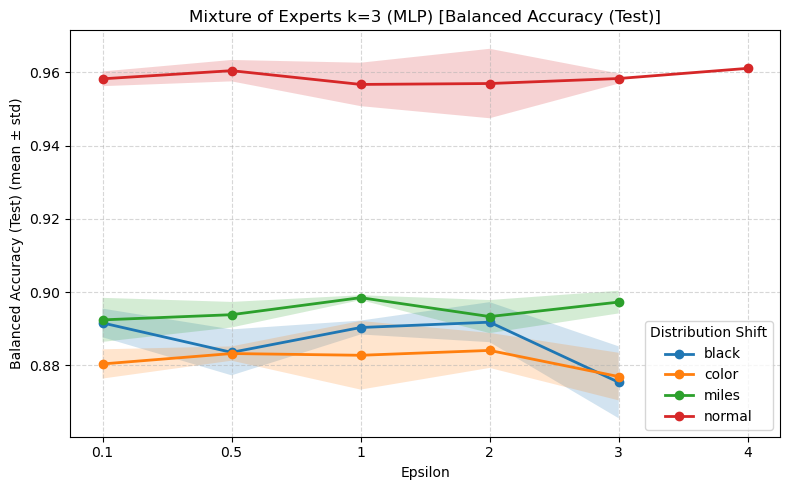

epsilon   Shift  test.acc           test.balanced_acc          
                        mean       std              mean       std
0      0.1   black  0.909856  0.001445          0.891614  0.003911
1      0.1   color  0.912211  0.003858          0.880421  0.003989
2      0.1   miles  0.909824  0.003870          0.892448  0.006013
3      0.1  normal  0.968667  0.002663          0.958243  0.002008
4      0.5   black  0.903686  0.005306          0.883578  0.006270
5      0.5   color  0.915283  0.004373          0.883260  0.001952
6      0.5   miles  0.910989  0.003822          0.893860  0.003486
7      0.5  normal  0.968240  0.002104          0.960465  0.002920
8      1.0   black  0.905649  0.002310          0.890363  0.001890
9      1.0   color  0.911908  0.006343          0.882784  0.009361
10     1.0   miles  0.912476  0.000819          0.898510  0.000665
11     1.0  normal  0.966400  0.004200          0.956710  0.005926
12     2.0   black  0.911325  0.006143          0.891824  0.005464
13     2.0   color  0.914068  0.003823          0.884110  0.004779
14     2.0   miles  0.909840  0.001467          0.893349  0.004517
15     2.0  normal  0.965867  0.006300          0.956957  0.009476
16     3.0   black  0.898037  0.005705          0.875408  0.009812
17     3.0   color  0.908195  0.007670          0.876969  0.006500
18     3.0   miles  0.910922  0.002031          0.897304  0.003096
19     3.0  normal  0.966133  0.002003          0.958324  0.001375
20     4.0  normal  0.968000       NaN          0.961101       NaN

Shift epsilon  test.acc           test.balanced_acc          
                        mean       std              mean       std
12   black     2.0  0.911325  0.006143          0.891824  0.005464
13   color     2.0  0.914068  0.003823          0.884110  0.004779
10   miles     1.0  0.912476  0.000819          0.898510  0.000665
20  normal     4.0  0.968000       NaN          0.961101       NaN

test.acc           test.balanced_acc          
                 mean       std              mean       std
Shift                                                      
black        0.900908  0.011438          0.884244  0.012234
color_miles  0.917713  0.005891          0.891435  0.006215
miles        0.915788  0.005058          0.901881  0.006620
normal       0.966533  0.001701          0.960397  0.003545

In [73]:
plot_results(path="MoE3-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts k=3 (MLP)", base_path=BASE_DVM_PATH, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

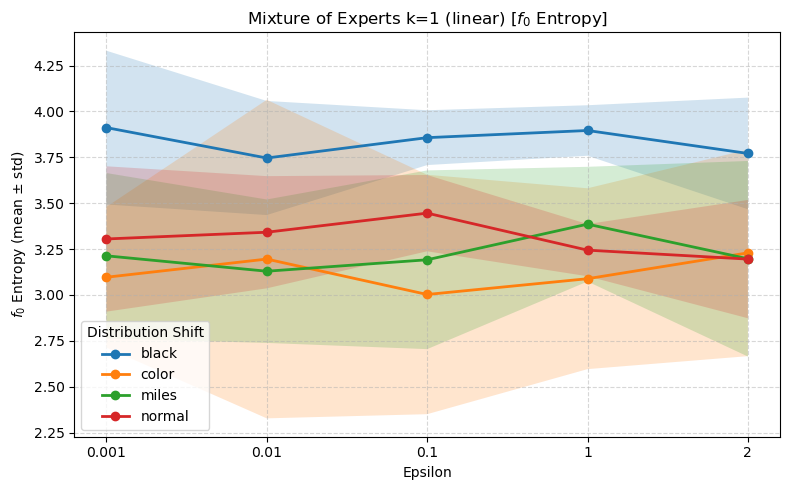

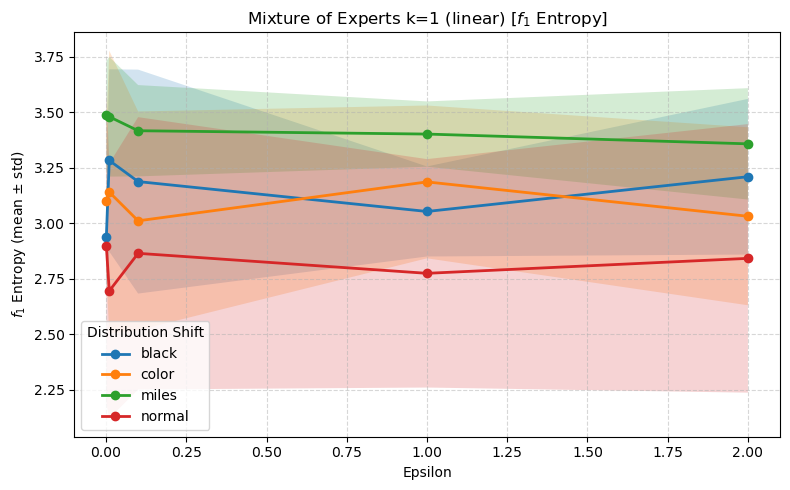

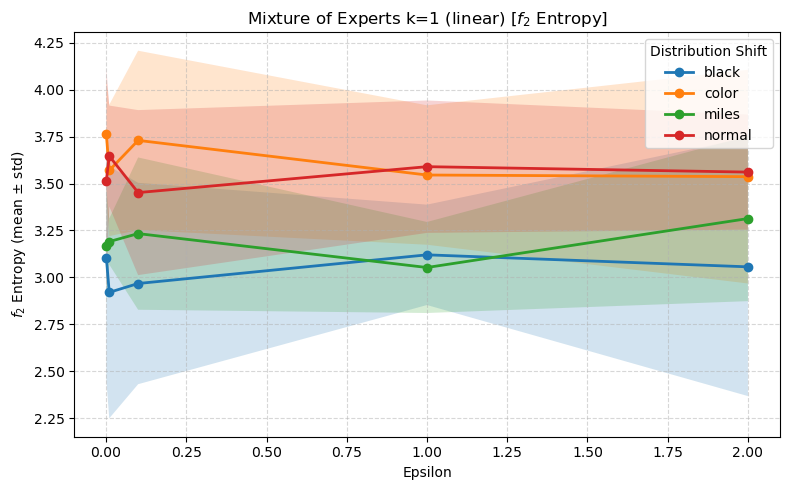

epsilon   Shift test.expert_no0.entropy           test.expert_no1.entropy  \
                                      mean       std                    mean   
0    0.001   black                3.911914  0.419010                2.937811   
1    0.001   color                3.096304  0.383112                3.099190   
2    0.001   miles                3.213141  0.451130                3.485731   
3    0.001  normal                3.304906  0.396136                2.897098   
4    0.010   black                3.746166  0.310935                3.282732   
5    0.010   color                3.195343  0.868034                3.140223   
6    0.010   miles                3.129180  0.390768                3.479542   
7    0.010  normal                3.341581  0.305739                2.695162   
8    0.100   black                3.857049  0.149371                3.187510   
9    0.100   color                3.002376  0.652379                3.010876   
10   0.100   miles                3.191480  0.487015                3.416407   
11   0.100  normal                3.445692  0.207911                2.864596   
12   1.000   black                3.896086  0.137633                3.052970   
13   1.000   color                3.088328  0.492764                3.186051   
14   1.000   miles                3.385640  0.312538                3.401398   
15   1.000  normal                3.243991  0.142254                2.774552   
16   2.000   black                3.771005  0.304260                3.209412   
17   2.000   color                3.229197  0.562929                3.031377   
18   2.000   miles                3.197025  0.532938                3.357407   
19   2.000  normal                3.195151  0.322358                2.841888   

             test.expert_no2.entropy            test.acc            \
         std                    mean       std      mean       std   
0   0.240564                3.105960  0.652691  0.875200  0.035942   
1   0.330922                3.761718  0.296254  0.897529  0.002997   
2   0.243935                3.167247  0.305076  0.899703  0.008451   
3   0.705349                3.515312  0.597429  0.959800  0.003079   
4   0.410239                2.920292  0.671141  0.892027  0.007699   
5   0.636356                3.569808  0.350010  0.898744  0.003215   
6   0.269501                3.190850  0.122555  0.897743  0.003543   
7   0.573361                3.646681  0.268673  0.959333  0.004636   
8   0.504011                2.967499  0.536412  0.875735  0.008751   
9   0.492213                3.729930  0.477729  0.905225  0.005438   
10  0.205526                3.233334  0.405694  0.898756  0.004082   
11  0.612901                3.451812  0.439517  0.953600  0.004015   
12  0.202607                3.120233  0.267414  0.877471  0.027300   
13  0.343932                3.545444  0.371426  0.892804  0.010916   
14  0.146914                3.052722  0.242424  0.897270  0.005257   
15  0.514117                3.589923  0.352668  0.957667  0.004456   
16  0.350314                3.056295  0.688575  0.889557  0.004851   
17  0.400618                3.536730  0.569156  0.898542  0.002724   
18  0.250598                3.313499  0.440018  0.893823  0.008473   
19  0.604494                3.561057  0.306336  0.957467  0.008524   

   test.balanced_acc            
                mean       std  
0           0.864091  0.025555  
1           0.872471  0.004642  
2           0.886404  0.007608  
3           0.952401  0.003451  
4           0.878863  0.007898  
5           0.874250  0.006571  
6           0.884367  0.005246  
7           0.952492  0.005100  
8           0.862696  0.002942  
9           0.880701  0.006610  
10          0.885906  0.002084  
11          0.943989  0.006181  
12          0.867089  0.027702  
13          0.865050  0.015629  
14          0.881895  0.007807  
15          0.951343  0.005658  
16          0.876262  0.008599  
17          0.870246  0.002803  
18          0.877655  0.006425  
19      

Shift epsilon  test.acc           test.balanced_acc          
                       mean       std              mean       std
4   black   0.010  0.892027  0.007699          0.878863  0.007898
9   color   0.100  0.905225  0.005438          0.880701  0.006610
2   miles   0.001  0.899703  0.008451          0.886404  0.007608
7  normal   0.010  0.959333  0.004636          0.952492  0.005100

test.acc           test.balanced_acc          
                 mean       std              mean       std
Shift                                                      
black        0.900908  0.011438          0.884244  0.012234
color_miles  0.917713  0.005891          0.891435  0.006215
miles        0.915788  0.005058          0.901881  0.006620
normal       0.966533  0.001701          0.960397  0.003545

In [74]:
plot_results(path="MoE1-MLP-Switch", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", base_path=BASE_DVM_PATH, metric=["test.expert_no0.entropy", "test.expert_no1.entropy", "test.expert_no2.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

## MoE k=1 Swift


Shift: black
MoE.test.weight0 max value: 0.3333333134651184
MoE.test.weight1 max value: 0.3333333134651184
MoE.test.weight2 max value: 0.3333333134651184

Shift: color
MoE.test.weight0 max value: 0.3333333134651184
MoE.test.weight1 max value: 0.3333333134651184
MoE.test.weight2 max value: 0.3333333134651184

Shift: miles
MoE.test.weight0 max value: 0.3333333134651184
MoE.test.weight1 max value: 0.3333333134651184
MoE.test.weight2 max value: 0.3333333134651184

Shift: normal
MoE.test.weight0 max value: 0.3333333134651184
MoE.test.weight1 max value: 0.3333333134651184
MoE.test.weight2 max value: 0.3333333134651184


Shift epsilon MoE.test.weight0     MoE.test.weight1     MoE.test.weight2  \
                               mean std             mean std             mean   
0    black   0.001         0.333333 NaN         0.333333 NaN         0.333333   
4    black    0.01         0.333333 NaN         0.333333 NaN         0.333333   
8    black     0.1         0.333333 NaN         0.333333 NaN         0.333333   
12   black       1         0.333333 NaN         0.333333 NaN         0.333333   
16   black       2         0.333333 NaN         0.333333 NaN         0.333333   
0    black   0.001         0.333333 NaN         0.333333 NaN         0.333333   
4    black    0.01         0.333333 NaN         0.333333 NaN         0.333333   
8    black     0.1         0.333333 NaN         0.333333 NaN         0.333333   
12   black       1         0.333333 NaN         0.333333 NaN         0.333333   
16   black       2         0.333333 NaN         0.333333 NaN         0.333333   
0    black   0.001         0.333333 NaN         0.333333 NaN         0.333333   
4    black    0.01         0.333333 NaN         0.333333 NaN         0.333333   
8    black     0.1         0.333333 NaN         0.333333 NaN         0.333333   
12   black       1         0.333333 NaN         0.333333 NaN         0.333333   
16   black       2         0.333333 NaN         0.333333 NaN         0.333333   
1    color   0.001         0.333333 NaN         0.333333 NaN         0.333333   
5    color    0.01         0.333333 NaN         0.333333 NaN         0.333333   
9    color     0.1         0.333333 NaN         0.333333 NaN         0.333333   
13   color       1         0.333333 NaN         0.333333 NaN         0.333333   
17   color       2         0.333333 NaN         0.333333 NaN         0.333333   
1    color   0.001         0.333333 NaN         0.333333 NaN         0.333333   
5    color    0.01         0.333333 NaN         0.333333 NaN         0.333333   
9    color     0.1         0.333333 NaN         0.333333 NaN         0.333333   
13   color       1         0.333333 NaN         0.333333 NaN         0.333333   
17   color       2         0.333333 NaN         0.333333 NaN         0.333333   
1    color   0.001         0.333333 NaN         0.333333 NaN         0.333333   
5    color    0.01         0.333333 NaN         0.333333 NaN         0.333333   
9    color     0.1         0.333333 NaN         0.333333 NaN         0.333333   
13   color       1         0.333333 NaN         0.333333 NaN         0.333333   
17   color       2         0.333333 NaN         0.333333 NaN         0.333333   
2    miles   0.001         0.333333 NaN         0.333333 NaN         0.333333   
6    miles    0.01         0.333333 NaN         0.333333 NaN         0.333333   
10   miles     0.1         0.333333 NaN         0.333333 NaN         0.333333   
14   miles       1         0.333333 NaN         0.333333 NaN         0.333333   
18   miles       2         0.333333 NaN         0.333333 NaN         0.333333   
2    miles   0.001         0.333333 NaN         0.333333 NaN         0.333333   
6    miles    0.01         0.333333 NaN         0.333333 NaN         0.333333   
10   miles     0.1         0.333333 NaN         0.333333 NaN         0.333333   
14   miles       1         0.333333 NaN         0.333333 NaN         0.333333   
18   miles       2         0.333333 NaN         0.333333 NaN         0.333333   
2    miles   0.001         0.333333 NaN         0.333333 NaN         0.333333   
6    miles    0.01         0.333333 NaN         0.333333 NaN         0.333333   
10   miles     0.1         0.333333 NaN         0.333333 NaN         0.333333   
14   miles       1         0.333333 NaN         0.333333 NaN         0.333333   
18   miles       2         0.333333 NaN         0.333333 NaN         0.333333   
3   normal   0.001         0.333333 NaN         0.333333 NaN         0.333333   
7   normal    0.01         0.333333 NaN         0.333333 NaN         0.333333   
11  normal     0.1         0.333333 

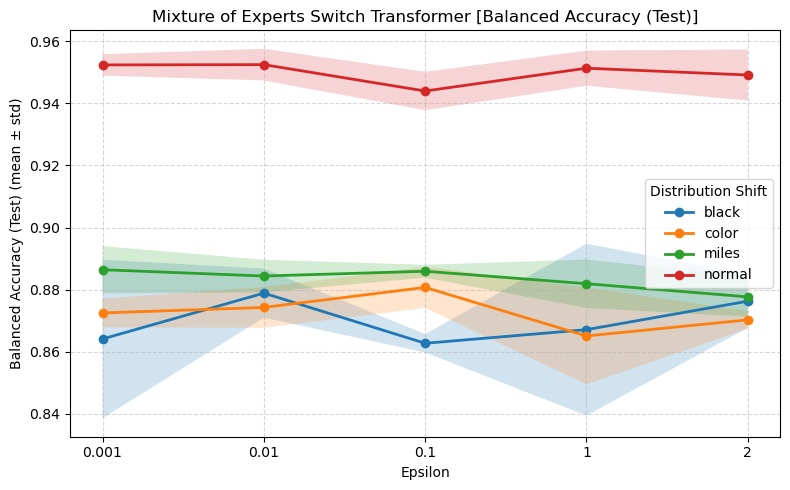

epsilon   Shift  test.acc           test.balanced_acc          
                        mean       std              mean       std
0    0.001   black  0.875200  0.035942          0.864091  0.025555
1    0.001   color  0.897529  0.002997          0.872471  0.004642
2    0.001   miles  0.899703  0.008451          0.886404  0.007608
3    0.001  normal  0.959800  0.003079          0.952401  0.003451
4    0.010   black  0.892027  0.007699          0.878863  0.007898
5    0.010   color  0.898744  0.003215          0.874250  0.006571
6    0.010   miles  0.897743  0.003543          0.884367  0.005246
7    0.010  normal  0.959333  0.004636          0.952492  0.005100
8    0.100   black  0.875735  0.008751          0.862696  0.002942
9    0.100   color  0.905225  0.005438          0.880701  0.006610
10   0.100   miles  0.898756  0.004082          0.885906  0.002084
11   0.100  normal  0.953600  0.004015          0.943989  0.006181
12   1.000   black  0.877471  0.027300          0.867089  0.027702
13   1.000   color  0.892804  0.010916          0.865050  0.015629
14   1.000   miles  0.897270  0.005257          0.881895  0.007807
15   1.000  normal  0.957667  0.004456          0.951343  0.005658
16   2.000   black  0.889557  0.004851          0.876262  0.008599
17   2.000   color  0.898542  0.002724          0.870246  0.002803
18   2.000   miles  0.893823  0.008473          0.877655  0.006425
19   2.000  normal  0.957467  0.008524          0.949152  0.008231

Shift epsilon  test.acc           test.balanced_acc          
                       mean       std              mean       std
4   black   0.010  0.892027  0.007699          0.878863  0.007898
9   color   0.100  0.905225  0.005438          0.880701  0.006610
2   miles   0.001  0.899703  0.008451          0.886404  0.007608
7  normal   0.010  0.959333  0.004636          0.952492  0.005100

test.acc           test.balanced_acc          
                 mean       std              mean       std
Shift                                                      
black        0.900908  0.011438          0.884244  0.012234
color_miles  0.917713  0.005891          0.891435  0.006215
miles        0.915788  0.005058          0.901881  0.006620
normal       0.966533  0.001701          0.960397  0.003545

In [75]:
plot_results(path="MoE1-MLP-Switch", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric="test.balanced_acc", title="Mixture of Experts Switch Transformer", base_path=BASE_DVM_PATH, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

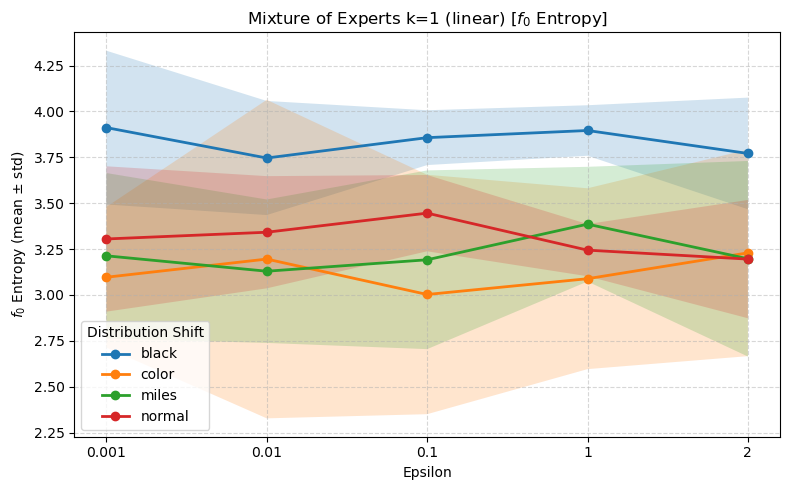

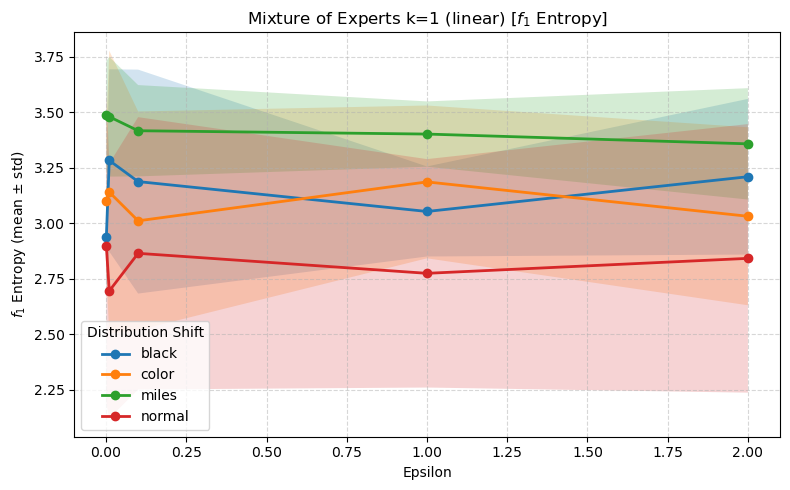

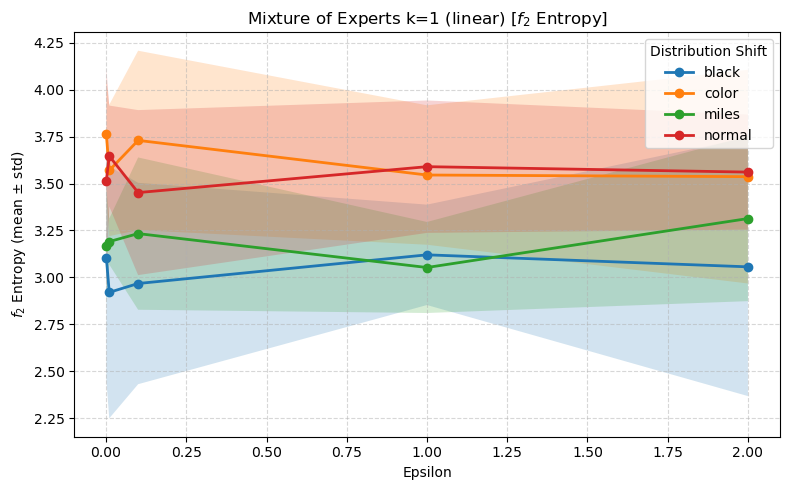

epsilon   Shift test.expert_no0.entropy           test.expert_no1.entropy  \
                                      mean       std                    mean   
0    0.001   black                3.911914  0.419010                2.937811   
1    0.001   color                3.096304  0.383112                3.099190   
2    0.001   miles                3.213141  0.451130                3.485731   
3    0.001  normal                3.304906  0.396136                2.897098   
4    0.010   black                3.746166  0.310935                3.282732   
5    0.010   color                3.195343  0.868034                3.140223   
6    0.010   miles                3.129180  0.390768                3.479542   
7    0.010  normal                3.341581  0.305739                2.695162   
8    0.100   black                3.857049  0.149371                3.187510   
9    0.100   color                3.002376  0.652379                3.010876   
10   0.100   miles                3.191480  0.487015                3.416407   
11   0.100  normal                3.445692  0.207911                2.864596   
12   1.000   black                3.896086  0.137633                3.052970   
13   1.000   color                3.088328  0.492764                3.186051   
14   1.000   miles                3.385640  0.312538                3.401398   
15   1.000  normal                3.243991  0.142254                2.774552   
16   2.000   black                3.771005  0.304260                3.209412   
17   2.000   color                3.229197  0.562929                3.031377   
18   2.000   miles                3.197025  0.532938                3.357407   
19   2.000  normal                3.195151  0.322358                2.841888   

             test.expert_no2.entropy            test.acc            \
         std                    mean       std      mean       std   
0   0.240564                3.105960  0.652691  0.875200  0.035942   
1   0.330922                3.761718  0.296254  0.897529  0.002997   
2   0.243935                3.167247  0.305076  0.899703  0.008451   
3   0.705349                3.515312  0.597429  0.959800  0.003079   
4   0.410239                2.920292  0.671141  0.892027  0.007699   
5   0.636356                3.569808  0.350010  0.898744  0.003215   
6   0.269501                3.190850  0.122555  0.897743  0.003543   
7   0.573361                3.646681  0.268673  0.959333  0.004636   
8   0.504011                2.967499  0.536412  0.875735  0.008751   
9   0.492213                3.729930  0.477729  0.905225  0.005438   
10  0.205526                3.233334  0.405694  0.898756  0.004082   
11  0.612901                3.451812  0.439517  0.953600  0.004015   
12  0.202607                3.120233  0.267414  0.877471  0.027300   
13  0.343932                3.545444  0.371426  0.892804  0.010916   
14  0.146914                3.052722  0.242424  0.897270  0.005257   
15  0.514117                3.589923  0.352668  0.957667  0.004456   
16  0.350314                3.056295  0.688575  0.889557  0.004851   
17  0.400618                3.536730  0.569156  0.898542  0.002724   
18  0.250598                3.313499  0.440018  0.893823  0.008473   
19  0.604494                3.561057  0.306336  0.957467  0.008524   

   test.balanced_acc            
                mean       std  
0           0.864091  0.025555  
1           0.872471  0.004642  
2           0.886404  0.007608  
3           0.952401  0.003451  
4           0.878863  0.007898  
5           0.874250  0.006571  
6           0.884367  0.005246  
7           0.952492  0.005100  
8           0.862696  0.002942  
9           0.880701  0.006610  
10          0.885906  0.002084  
11          0.943989  0.006181  
12          0.867089  0.027702  
13          0.865050  0.015629  
14          0.881895  0.007807  
15          0.951343  0.005658  
16          0.876262  0.008599  
17          0.870246  0.002803  
18          0.877655  0.006425  
19      

Shift epsilon  test.acc           test.balanced_acc          
                       mean       std              mean       std
4   black   0.010  0.892027  0.007699          0.878863  0.007898
9   color   0.100  0.905225  0.005438          0.880701  0.006610
2   miles   0.001  0.899703  0.008451          0.886404  0.007608
7  normal   0.010  0.959333  0.004636          0.952492  0.005100

test.acc           test.balanced_acc          
                 mean       std              mean       std
Shift                                                      
black        0.900908  0.011438          0.884244  0.012234
color_miles  0.917713  0.005891          0.891435  0.006215
miles        0.915788  0.005058          0.901881  0.006620
normal       0.966533  0.001701          0.960397  0.003545

In [76]:
plot_results(path="MoE1-MLP-Switch", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", base_path=BASE_DVM_PATH, metric=["test.expert_no0.entropy", "test.expert_no1.entropy", "test.expert_no2.entropy"], title="Mixture of Experts k=1 (linear)", just_plot=True, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")

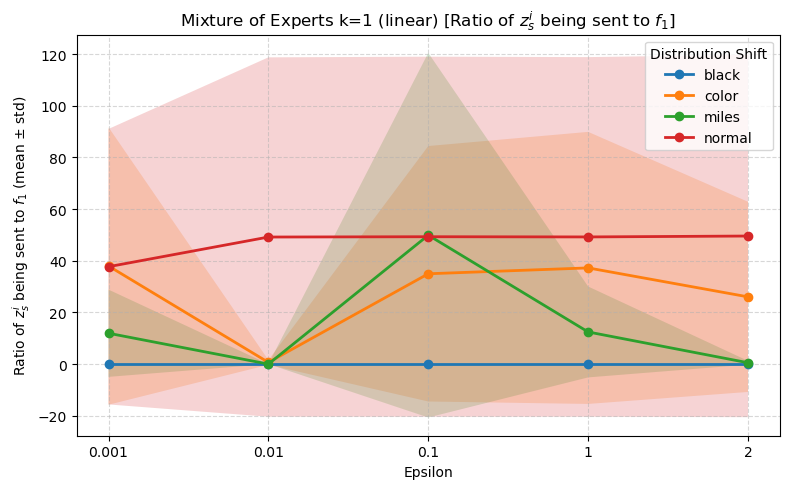

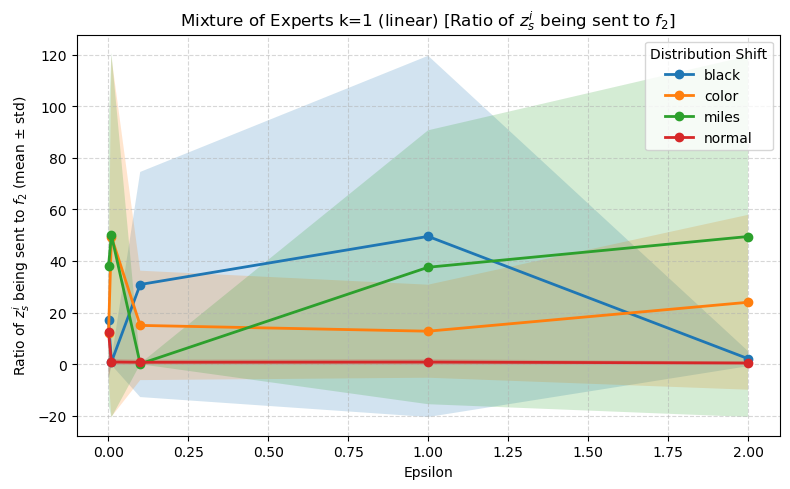

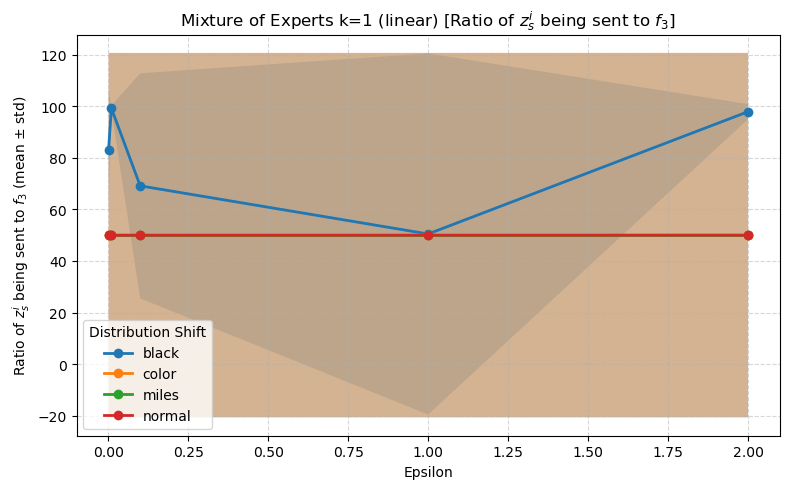

epsilon   Shift MoE.test.x_ai.class_prob_0             \
                                         mean        std   
0    0.001   black                   0.000000   0.000000   
1    0.001   color                  37.970837  53.698872   
2    0.001   miles                  11.942417  16.889128   
3    0.001  normal                  37.700001  53.315852   
4    0.010   black                   0.000000   0.000000   
5    0.010   color                   0.658161   0.930781   
6    0.010   miles                   0.000000   0.000000   
7    0.010  normal                  49.180000  69.551023   
8    0.100   black                   0.000000   0.000000   
9    0.100   color                  34.963547  49.445922   
10   0.100   miles                  49.898621  70.567306   
11   0.100  normal                  49.300001  69.692446   
12   1.000   black                   0.000000   0.000000   
13   1.000   color                  37.231674  52.653539   
14   1.000   miles                  12.439173  17.591647   
15   1.000  normal                  49.220001  69.607593   
16   2.000   black                   0.000000   0.000000   
17   2.000   color                  26.022682  36.801630   
18   2.000   miles                   0.517032   0.731193   
19   2.000  normal                  49.570000  70.102566   

   MoE.test.x_ai.class_prob_1            MoE.test.x_ai.class_prob_2  \
                         mean        std                       mean   
0                   17.087339  23.570225                  82.912663   
1                   12.039287  16.997484                  49.989876   
2                   38.057583  53.821550                  50.000000   
3                   12.300000  17.394827                  50.000000   
4                    0.791266   1.119019                  99.208733   
5                   49.341839  69.779898                  50.000000   
6                   50.000000  70.710678                  50.000000   
7                    0.820000   1.159655                  50.000000   
8                   30.869390  43.655911                  69.130610   
9                   15.006075  21.221795                  50.030377   
10                   0.101379   0.143371                  50.000000   
11                   0.710000   1.004092                  49.990002   
12                  49.529247  70.044933                  50.470753   
13                  12.758202  18.042822                  50.010126   
14                  37.560825  53.119029                  50.000000   
15                   0.780000   1.103087                  50.000000   
16                   2.103365   2.917949                  97.896637   
17                  23.977318  33.909048                  50.000000   
18                  49.482967  69.979484                  50.000000   
19                   0.420000   0.593970                  50.010000   

               test.acc           test.balanced_acc            
          std      mean       std              mean       std  
0   23.570228  0.875200  0.035942          0.864091  0.025555  
1   70.696360  0.897529  0.002997          0.872471  0.004642  
2   70.710678  0.899703  0.008451          0.886404  0.007608  
3   70.710678  0.959800  0.003079          0.952401  0.003451  
4    1.119021  0.892027  0.007699          0.878863  0.007898  
5   70.710678  0.898744  0.003215          0.874250  0.006571  
6   70.710678  0.897743  0.003543          0.884367  0.005246  
7   70.710678  0.959333  0.004636          0.952492  0.005100  
8   43.655911  0.875735  0.008751          0.862696  0.002942  
9   70.667719  0.905225  0.005438          0.880701  0.006610  
10  70.710678  0.898756  0.004082          0.885906  0.002084  
11  70.696538  0.953600  0.004015          0.943989  0.006181  
12  70.044933  0.877471  0.027300          0.867089  0.027702  
13  70.696358  0.892804  0.010916          0.865050  0.015629  
14  70.710678  0.897270  0.005257          0.881895  0.007807  
15  70.710678  0.957667  0.0044

Shift epsilon  test.acc           test.balanced_acc          
                       mean       std              mean       std
4   black   0.010  0.892027  0.007699          0.878863  0.007898
9   color   0.100  0.905225  0.005438          0.880701  0.006610
2   miles   0.001  0.899703  0.008451          0.886404  0.007608
7  normal   0.010  0.959333  0.004636          0.952492  0.005100

test.acc           test.balanced_acc          
                 mean       std              mean       std
Shift                                                      
black        0.900908  0.011438          0.884244  0.012234
color_miles  0.917713  0.005891          0.891435  0.006215
miles        0.915788  0.005058          0.901881  0.006620
normal       0.966533  0.001701          0.960397  0.003545

In [77]:
plot_results(path="MoE1-MLP-Switch", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=["MoE.test.x_ai.class_prob_0", "MoE.test.x_ai.class_prob_1", "MoE.test.x_ai.class_prob_2"], title="Mixture of Experts k=1 (linear)", just_plot=True, base_path=BASE_DVM_PATH, pattern=r"MoE_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_|dvm_all_server_reordered_SemiPseudo_TIP)_([a-zA-Z]+)_(?:seed)?")